### Notebook 02 — Análisis de Notas Académicas
### Sistema de Alerta Temprana · IIND-2104 Modelos Probabilísticos · Universidad de los Andes

Propósito de este notebook
Este notebook caracteriza en profundidad el rendimiento académico de los estudiantes activos (APROBÓ / REPROBÓ) a través de las evaluaciones formales del curso. Responde cuatro preguntas:

¿Cómo se distribuye la nota final? Vista general, por era y por semestre.
¿Qué tan discriminativos son los parciales? Análisis de P1, P2 y P3 como señales de alerta.
¿Qué revelan las evaluaciones continuas? AMs, quices y talleres según semestre y modalidad.
¿Qué trayectorias siguen los estudiantes? Patrones P1→P2→P3 y su relación con el resultado final.

Subconjunto utilizado
SubsetNDescripcióndf_activos554APROBÓ (413) + REPROBÓ (141). Sin retirados ni sin nota.df_activos_engagement502Subconjunto anterior con engagement > 0. Para análisis combinados.

Nota sobre nulos en df_activos: Los tres parciales y la nota final están completos en los 554 registros activos (0 nulos). Los ceros en parcial_2 (7 casos) y parcial_3 (15 casos) corresponden a ausencias reales a evaluaciones, no datos faltantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Paleta del proyecto (consistente con NB01) ────────────────────────────────
PALETA_ESTADO = {
    'APROBÓ':   '#2ecc71',
    'REPROBÓ':  '#e74c3c',
}
PALETA_ERA = {
    'formato_antiguo': '#2c3e50',
    'formato_nuevo':   '#e67e22',
}
PALETA_SEMESTRE = {
    202320: '#1a3a5c',
    202410: '#2471a3',
    202420: '#e67e22',
    202510: '#ca6f1e',
    202520: '#784212',
}

plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':         True,
    'grid.color':        'white',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
})

# ── Carga de datos ────────────────────────────────────────────────────────────
df_activos            = pd.read_csv('../data/subsets/df_activos.csv')
df_activos_engagement = pd.read_csv('../data/subsets/df_activos_engagement.csv')

df_activos['semestre']            = df_activos['semestre'].astype(int)
df_activos_engagement['semestre'] = df_activos_engagement['semestre'].astype(int)

semestres = sorted(df_activos['semestre'].unique())
print(f"df_activos: {df_activos.shape}")
print(f"APROBÓ: {(df_activos['estado']=='APROBÓ').sum()} | REPROBÓ: {(df_activos['estado']=='REPROBÓ').sum()}")

df_activos: (554, 77)
APROBÓ: 413 | REPROBÓ: 141


### Sección 1 — Distribución de la Nota Final
La nota final (nota_100) es la variable objetivo principal de los modelos de regresión. Antes de analizar predictores, conviene entender su distribución completa: forma, asimetría, diferencias entre grupos y evolución temporal.
La escala es 0.0–5.0 (aprobación en ≥ 3.0). Valores superiores a 5.0 son posibles por bonificaciones pero infrecuentes. Una observación inmediata de los datos: no existe solapamiento en las medianas — APROBÓ mediana=3.62, REPROBÓ mediana=2.63 — lo que indica que los grupos son claramente separables y que un modelo predictivo tiene base estadística sólida.

### 1.1 Vista general: histograma + KDE por estado + violin por semestre

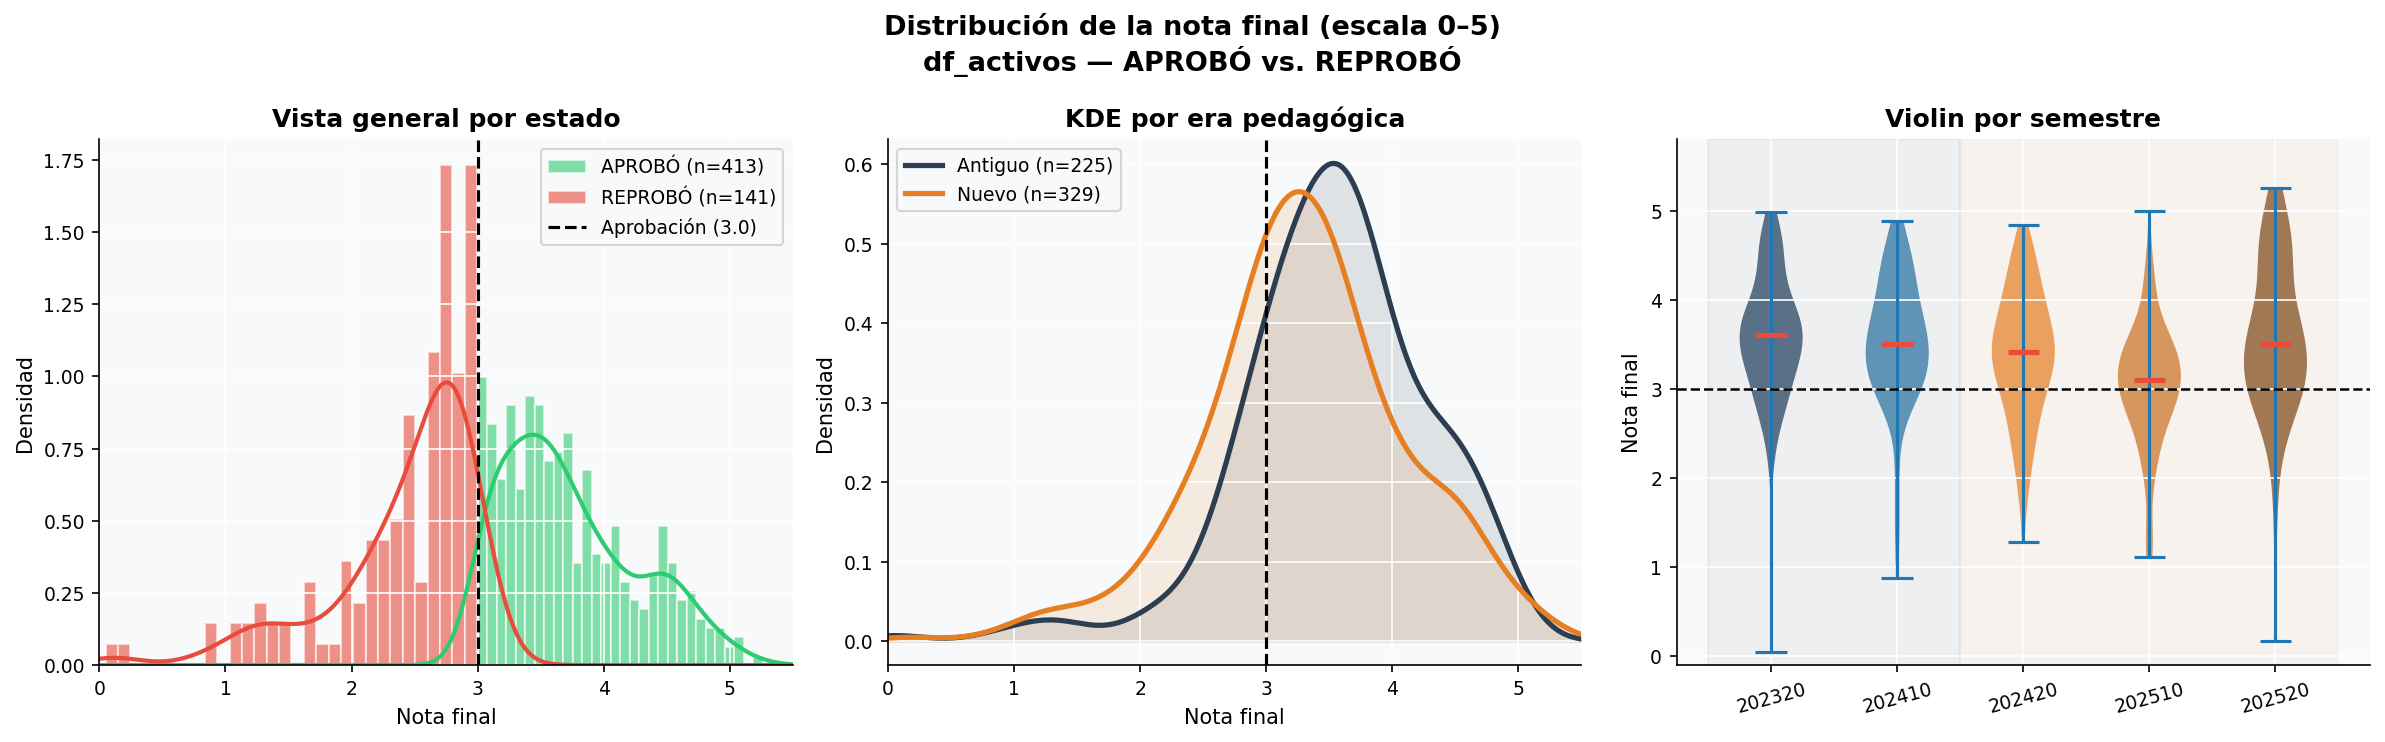

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de la nota final (escala 0–5)\ndf_activos — APROBÓ vs. REPROBÓ',
             fontsize=13, fontweight='bold')

# ── Panel A: Histograma superpuesto por estado ────────────────────────────────
ax = axes[0]
for estado in ['APROBÓ', 'REPROBÓ']:
    data = df_activos[df_activos['estado'] == estado]['nota_100']
    ax.hist(data, bins=30, alpha=0.60, color=PALETA_ESTADO[estado],
            label=f'{estado} (n={len(data)})', edgecolor='white', density=True)
    kde_x = np.linspace(0, 5.5, 300)
    kde = gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=PALETA_ESTADO[estado], linewidth=2)

ax.axvline(3.0, color='black', linestyle='--', linewidth=1.5, label='Aprobación (3.0)')
ax.set_xlabel('Nota final'); ax.set_ylabel('Densidad')
ax.set_xlim(0, 5.5); ax.set_title('Vista general por estado', fontweight='bold')
ax.legend()

# ── Panel B: KDE por era ───────────────────────────────────────────────────────
ax2 = axes[1]
for era in ['formato_antiguo', 'formato_nuevo']:
    data = df_activos[df_activos['era'] == era]['nota_100']
    label = f"{'Antiguo' if 'antiguo' in era else 'Nuevo'} (n={len(data)})"
    kde = gaussian_kde(data)
    kde_x = np.linspace(0, 5.5, 300)
    ax2.plot(kde_x, kde(kde_x), linewidth=2.5, color=PALETA_ERA[era], label=label)
    ax2.fill_between(kde_x, kde(kde_x), alpha=0.12, color=PALETA_ERA[era])

ax2.axvline(3.0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Nota final'); ax2.set_ylabel('Densidad')
ax2.set_xlim(0, 5.5); ax2.set_title('KDE por era pedagógica', fontweight='bold')
ax2.legend()

# ── Panel C: Violin por semestre ──────────────────────────────────────────────
ax3 = axes[2]
data_violin = [df_activos[df_activos['semestre'] == s]['nota_100'].values for s in semestres]
parts = ax3.violinplot(data_violin, positions=range(len(semestres)),
                       showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETA_SEMESTRE[semestres[i]]); pc.set_alpha(0.7)
parts['cmedians'].set_color('#e74c3c'); parts['cmedians'].set_linewidth(2.5)

ax3.axhline(3.0, color='black', linestyle='--', linewidth=1.2)
ax3.set_xticks(range(len(semestres)))
ax3.set_xticklabels([str(s) for s in semestres], rotation=15)
ax3.set_ylabel('Nota final'); ax3.set_ylim(-0.1, 5.8)
ax3.set_title('Violin por semestre', fontweight='bold')
ax3.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax3.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

plt.tight_layout()
plt.savefig('../figures/02_nota_final_distribucion.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.2 Tabla de estadísticos descriptivos: general, por era, por semestre

In [3]:
print("=" * 75)
print("ESTADÍSTICOS DESCRIPTIVOS — NOTA FINAL (df_activos)")
print("=" * 75)

# ── Vista general ──────────────────────────────────────────────────────────────
print("\n── Vista general ──────────────────────────────────────────────────────")
desc_gen = df_activos.groupby('estado')['nota_100'].agg(
    N='count', Media='mean', Mediana='median', Std='std',
    P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75),
    Min='min', Max='max'
).round(3)
print(desc_gen.to_string())

# ── Por era ────────────────────────────────────────────────────────────────────
print("\n── Por era pedagógica ─────────────────────────────────────────────────")
desc_era = df_activos.groupby(['era', 'estado'])['nota_100'].agg(
    N='count', Media='mean', Mediana='median', Std='std'
).round(3)
print(desc_era.to_string())

# ── Por semestre ───────────────────────────────────────────────────────────────
print("\n── Por semestre ───────────────────────────────────────────────────────")
desc_sem = df_activos.groupby(['semestre', 'estado'])['nota_100'].agg(
    N='count', Media='mean', Mediana='median', Std='std'
).round(3)
print(desc_sem.to_string())

ESTADÍSTICOS DESCRIPTIVOS — NOTA FINAL (df_activos)

── Vista general ──────────────────────────────────────────────────────
           N  Media  Mediana    Std   P25   P75   Min    Max
estado                                                      
APROBÓ   413  3.724    3.620  0.527  3.30  4.07  3.00  5.260
REPROBÓ  141  2.418    2.632  0.583  2.24  2.81  0.05  2.996

── Por era pedagógica ─────────────────────────────────────────────────
                           N  Media  Mediana    Std
era             estado                             
formato_antiguo APROBÓ   184  3.777    3.680  0.504
                REPROBÓ   41  2.446    2.720  0.671
formato_nuevo   APROBÓ   229  3.682    3.530  0.541
                REPROBÓ  100  2.407    2.605  0.545

── Por semestre ───────────────────────────────────────────────────────
                    N  Media  Mediana    Std
semestre estado                             
202320   APROBÓ   116  3.799    3.690  0.503
         REPROBÓ   27  2.480    2.730 

### Sección 2 — Análisis de los Parciales
Los parciales representan el 70% del curso (P1: 20%, P2: 25%, P3: 25%) y son las únicas evaluaciones presentes y comparables en todos los semestres. Su análisis es el corazón del sistema de alerta temprana.
La correlación con nota_100 aumenta progresivamente: P1 (r=0.69), P2 (r=0.76), P3 (r=0.82). Esto confirma que cada parcial adicional mejora la predicción, pero P1 ya captura información muy valiosa a tiempo — es la variable que activa el Checkpoint 1 en la semana 6 con ~11 semanas de margen de intervención.
Un hallazgo importante: la diferencia de medias entre APROBÓ y REPROBÓ crece con cada parcial (P1: +1.06 pts, P2: +1.42 pts, P3: +1.70 pts), lo que indica que los grupos divergen progresivamente a lo largo del semestre. Los REPROBÓ no mantienen el ritmo en P2 y P3.

### 2.1 Distribuciones de P1, P2, P3 por estado y por semestre

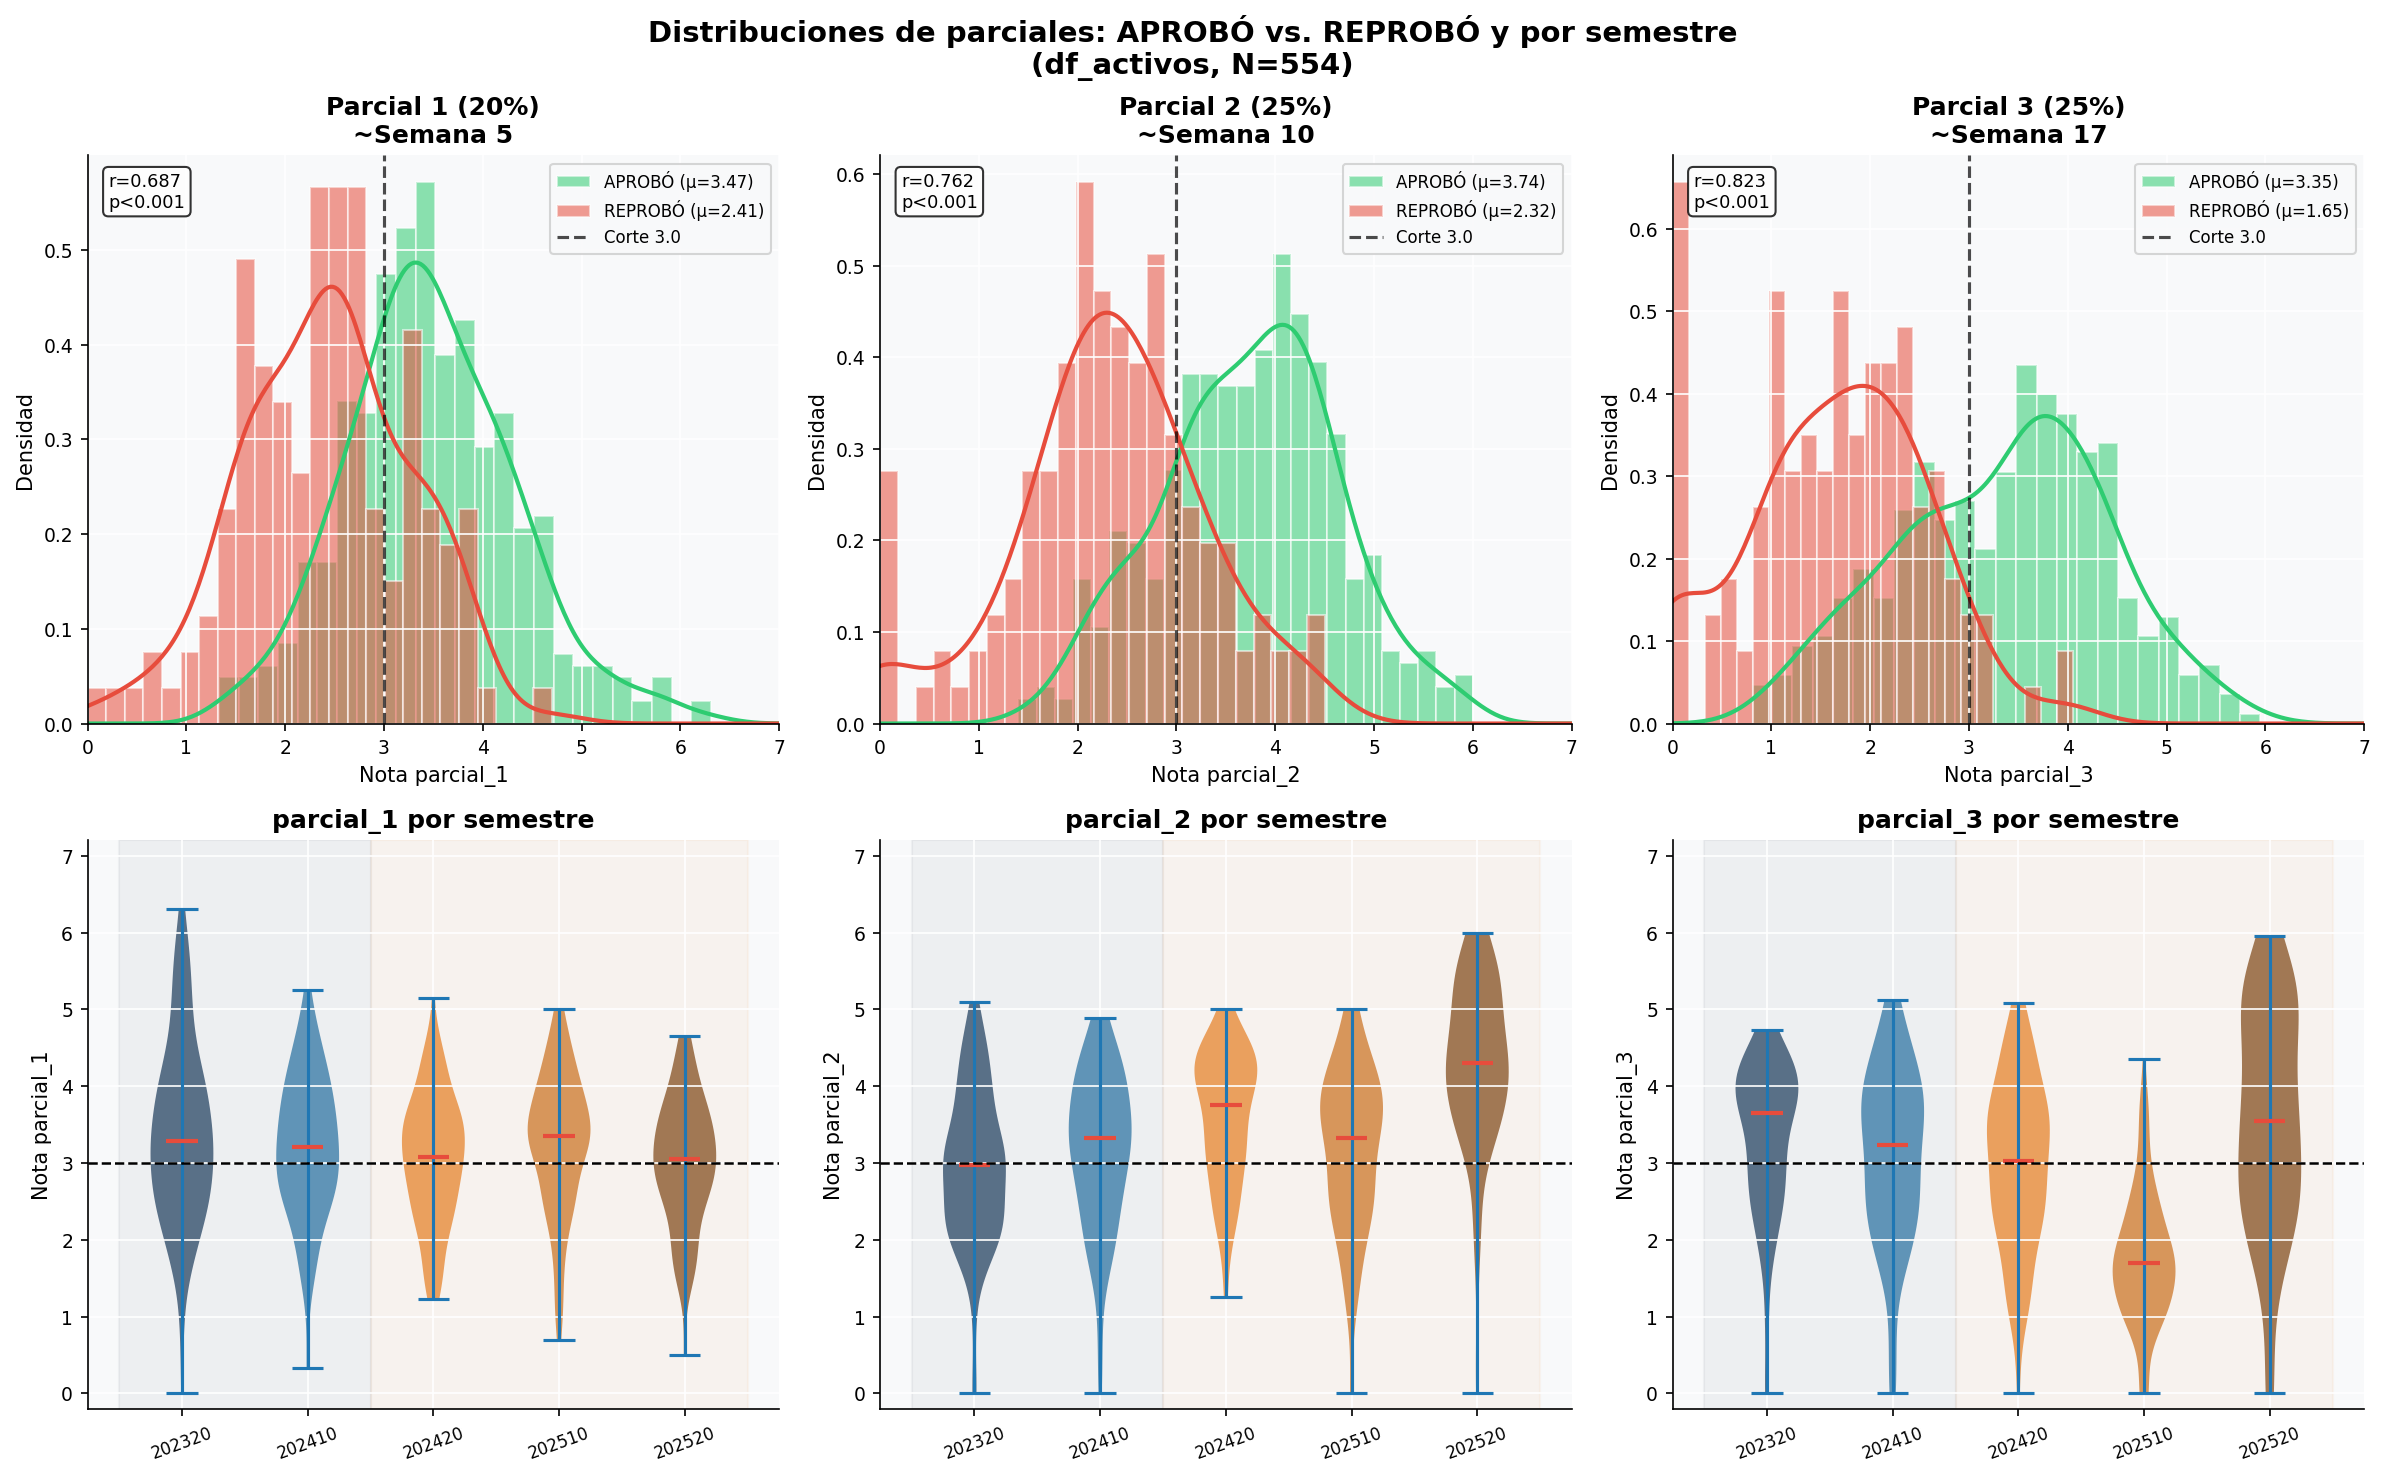

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuciones de parciales: APROBÓ vs. REPROBÓ y por semestre\n(df_activos, N=554)',
             fontsize=14, fontweight='bold')

parciales = ['parcial_1', 'parcial_2', 'parcial_3']
titulos   = ['Parcial 1 (20%)\n~Semana 5', 'Parcial 2 (25%)\n~Semana 10', 'Parcial 3 (25%)\n~Semana 17']

for col_idx, (var, titulo) in enumerate(zip(parciales, titulos)):

    # ── Fila superior: histograma + KDE por estado ────────────────────────────
    ax = axes[0, col_idx]
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = df_activos[df_activos['estado'] == estado][var].dropna()
        ax.hist(data, bins=25, alpha=0.55, color=PALETA_ESTADO[estado],
                label=f'{estado} (μ={data.mean():.2f})', edgecolor='white', density=True)
        if len(data) > 5:
            kde_x = np.linspace(0, 7, 300)
            kde = gaussian_kde(data)
            ax.plot(kde_x, kde(kde_x), color=PALETA_ESTADO[estado], linewidth=2)

    ax.axvline(3.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Corte 3.0')
    ax.set_xlabel(f'Nota {var}'); ax.set_ylabel('Densidad')
    ax.set_xlim(0, 7); ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)

    # Anotación de correlación con nota_100
    r, p = stats.pearsonr(
        df_activos[var].dropna(),
        df_activos.loc[df_activos[var].notna(), 'nota_100']
    )
    ax.text(0.03, 0.97, f'r={r:.3f}\np<0.001',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # ── Fila inferior: violin por semestre ────────────────────────────────────
    ax2 = axes[1, col_idx]
    data_viol = [df_activos[df_activos['semestre'] == s][var].dropna().values for s in semestres]
    parts = ax2.violinplot(data_viol, positions=range(len(semestres)),
                           showmedians=True, showextrema=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(PALETA_SEMESTRE[semestres[i]]); pc.set_alpha(0.7)
    parts['cmedians'].set_color('#e74c3c'); parts['cmedians'].set_linewidth(2)

    ax2.axhline(3.0, color='black', linestyle='--', linewidth=1.2)
    ax2.set_xticks(range(len(semestres)))
    ax2.set_xticklabels([str(s) for s in semestres], rotation=20, fontsize=8)
    ax2.set_ylabel(f'Nota {var}'); ax2.set_ylim(-0.2, 7.2)
    ax2.set_title(f'{var} por semestre', fontweight='bold')
    ax2.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
    ax2.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

plt.tight_layout()
plt.savefig('../figures/02_parciales_distribucion.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Evolución de medias P1→P2→P3 por estado y semestre
La trayectoria de medias revela que los REPROBÓ experimentan una caída progresiva y más pronunciada que los APROBÓ a lo largo del semestre. Especialmente notable es la diferencia en P3: mientras que los APROBÓ caen ligeramente (P2=3.74 → P3=3.35), los REPROBÓ colapsan (P2=2.32 → P3=1.65), sugiriendo abandono efectivo hacia el final del semestre.

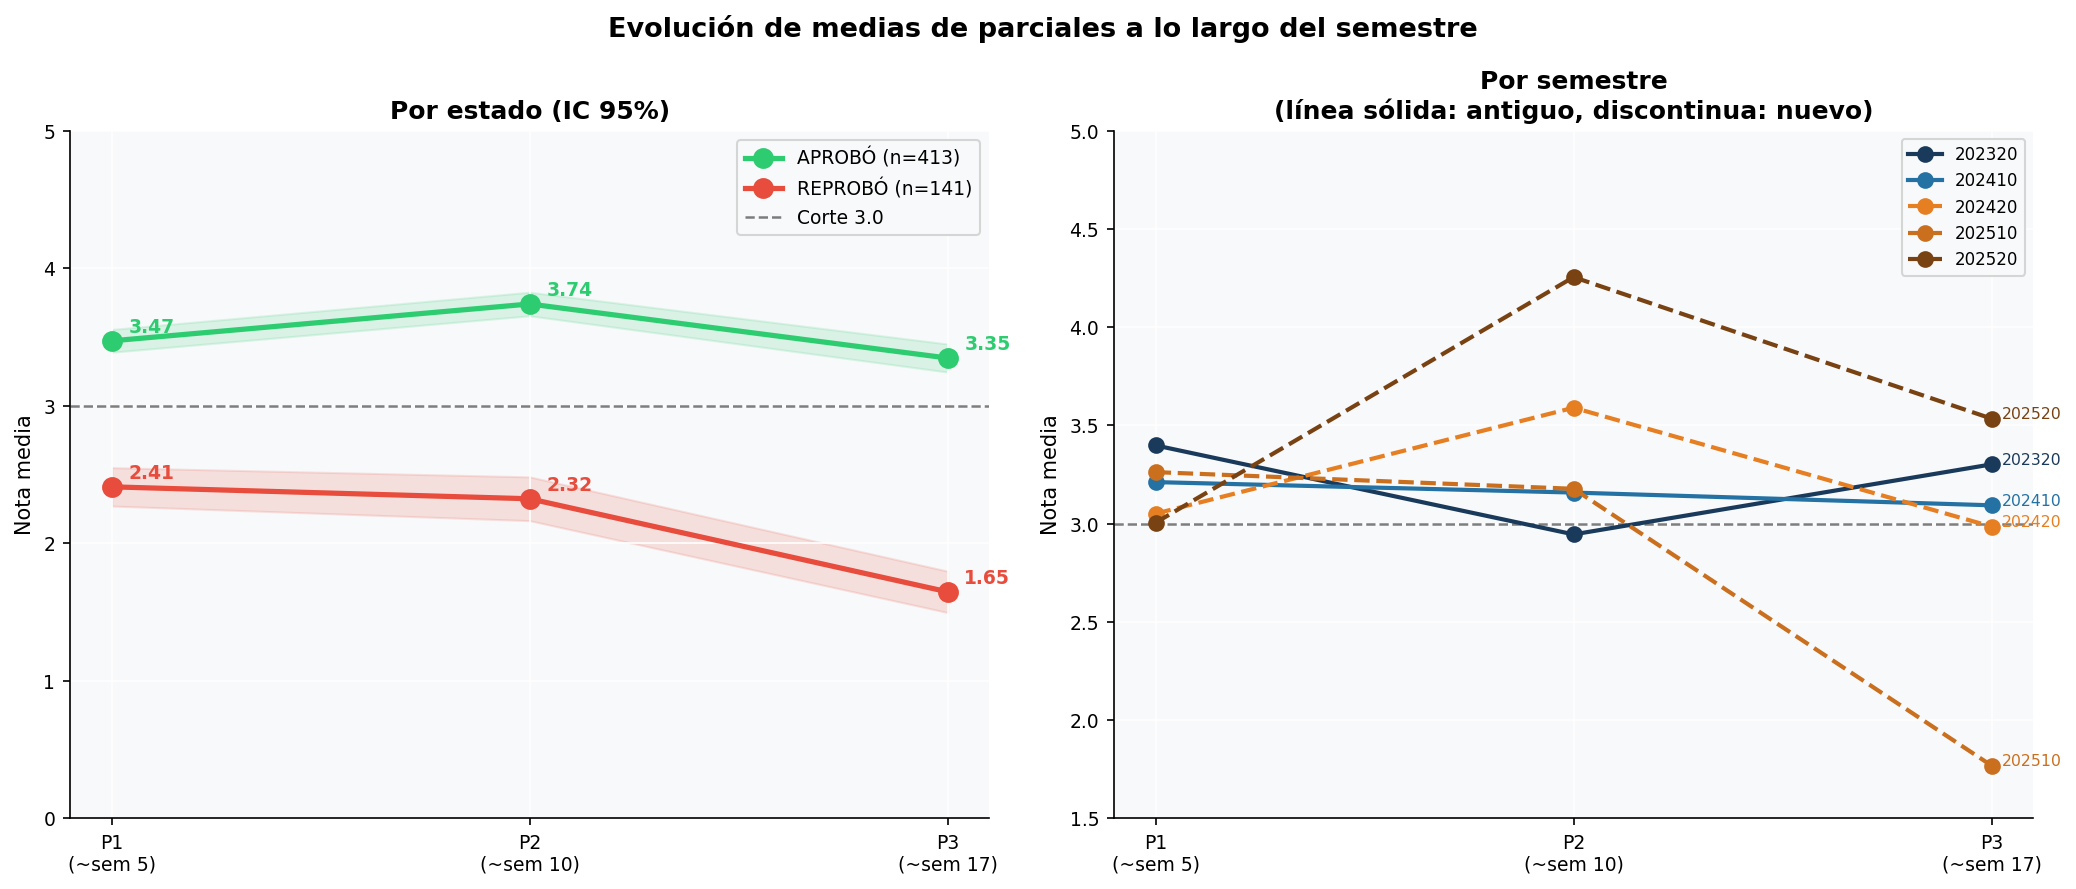

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evolución de medias de parciales a lo largo del semestre',
             fontsize=13, fontweight='bold')

checkpoints = ['parcial_1', 'parcial_2', 'parcial_3']
labels_ck   = ['P1\n(~sem 5)', 'P2\n(~sem 10)', 'P3\n(~sem 17)']

# ── Panel A: Por estado (con IC 95%) ──────────────────────────────────────────
ax = axes[0]
for estado in ['APROBÓ', 'REPROBÓ']:
    sub    = df_activos[df_activos['estado'] == estado]
    medias = [sub[p].mean() for p in checkpoints]
    errores = [sub[p].std() / np.sqrt(sub[p].notna().sum()) * 1.96 for p in checkpoints]

    ax.plot(range(3), medias, 'o-', color=PALETA_ESTADO[estado],
            linewidth=2.5, markersize=9, label=f'{estado} (n={len(sub)})', zorder=3)
    ax.fill_between(range(3),
                    [m - e for m, e in zip(medias, errores)],
                    [m + e for m, e in zip(medias, errores)],
                    alpha=0.15, color=PALETA_ESTADO[estado])
    for i, m in enumerate(medias):
        ax.annotate(f'{m:.2f}', (i, m),
                    textcoords='offset points', xytext=(8, 4),
                    fontsize=9, color=PALETA_ESTADO[estado], fontweight='bold')

ax.axhline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='Corte 3.0')
ax.set_xticks(range(3)); ax.set_xticklabels(labels_ck)
ax.set_ylabel('Nota media'); ax.set_ylim(0, 5)
ax.set_title('Por estado (IC 95%)', fontweight='bold')
ax.legend()

# ── Panel B: Por semestre ─────────────────────────────────────────────────────
ax2 = axes[1]
for sem in semestres:
    sub    = df_activos[df_activos['semestre'] == sem]
    medias = [sub[p].mean() for p in checkpoints]
    era    = sub['era'].iloc[0]
    ls     = '-' if era == 'formato_antiguo' else '--'
    ax2.plot(range(3), medias, 'o' + ls, color=PALETA_SEMESTRE[sem],
             linewidth=2, markersize=7, label=str(sem), zorder=3)
    ax2.annotate(str(sem), (2, medias[2]),
                 textcoords='offset points', xytext=(5, 0),
                 fontsize=7.5, color=PALETA_SEMESTRE[sem])

ax2.axhline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.set_xticks(range(3)); ax2.set_xticklabels(labels_ck)
ax2.set_ylabel('Nota media'); ax2.set_ylim(1.5, 5)
ax2.set_title('Por semestre\n(línea sólida: antiguo, discontinua: nuevo)',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_evolucion_medias_parciales.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Tabla de riesgo: P(resultado | intervalo P1)
Esta es la tabla más operativamente relevante del notebook. Define la probabilidad empírica de reprobación para cada rango de nota en P1, y constituye la base cuantitativa del sistema de niveles de alerta.

In [6]:
# ── Definir intervalos ────────────────────────────────────────────────────────
bins   = [0, 1.5, 2.5, 3.0, 3.5, 4.0, 7.0]
labels = ['[0, 1.5)', '[1.5, 2.5)', '[2.5, 3.0)', '[3.0, 3.5)', '[3.5, 4.0)', '[4.0+)']
niveles = ['CRÍTICO', 'ALTO', 'MODERADO', 'LÍMITE', 'SEGURO', 'SÓLIDO']

df_activos['intervalo_p1'] = pd.cut(df_activos['parcial_1'],
                                     bins=bins, labels=labels, right=False)

tabla_abs = pd.crosstab(df_activos['intervalo_p1'], df_activos['estado'])
tabla_pct = pd.crosstab(df_activos['intervalo_p1'], df_activos['estado'],
                         normalize='index').round(4)

print("=" * 72)
print("TABLA DE RIESGO — PROBABILIDAD DE RESULTADO SEGÚN INTERVALO DE P1")
print("=" * 72)
print(f"\n{'Intervalo P1':<14} {'Nivel':<11} {'N':>5} {'P(APROBÓ)':>11} {'P(REPROBÓ)':>11} {'Nota final media':>18}")
print("-" * 72)
for lbl, nivel in zip(labels, niveles):
    if lbl not in tabla_pct.index: continue
    n      = tabla_abs.loc[lbl].sum()
    p_ap   = tabla_pct.loc[lbl, 'APROBÓ']  if 'APROBÓ'  in tabla_pct.columns else 0
    p_rp   = tabla_pct.loc[lbl, 'REPROBÓ'] if 'REPROBÓ' in tabla_pct.columns else 0
    nota_m = df_activos[df_activos['intervalo_p1'] == lbl]['nota_100'].mean()
    print(f"  {lbl:<12} {nivel:<11} {n:>5} {p_ap:>10.1%} {p_rp:>11.1%} {nota_m:>17.3f}")
print("-" * 72)
print(f"\nP1 < 2.5  → P(REPROBÓ) > 57% — umbral de alerta temprana sugerido")
print(f"P1 ≥ 4.0  → P(REPROBÓ) < 1%  — zona sin riesgo")

TABLA DE RIESGO — PROBABILIDAD DE RESULTADO SEGÚN INTERVALO DE P1

Intervalo P1   Nivel           N   P(APROBÓ)  P(REPROBÓ)   Nota final media
------------------------------------------------------------------------
  [0, 1.5)     CRÍTICO        19      15.8%       84.2%             2.160
  [1.5, 2.5)   ALTO          102      43.1%       56.9%             2.797
  [2.5, 3.0)   MODERADO      100      68.0%       32.0%             3.103
  [3.0, 3.5)   LÍMITE        128      85.9%       14.1%             3.436
  [3.5, 4.0)   SEGURO         95      83.2%       16.8%             3.616
  [4.0+)       SÓLIDO        110      99.1%        0.9%             4.175
------------------------------------------------------------------------

P1 < 2.5  → P(REPROBÓ) > 57% — umbral de alerta temprana sugerido
P1 ≥ 4.0  → P(REPROBÓ) < 1%  — zona sin riesgo


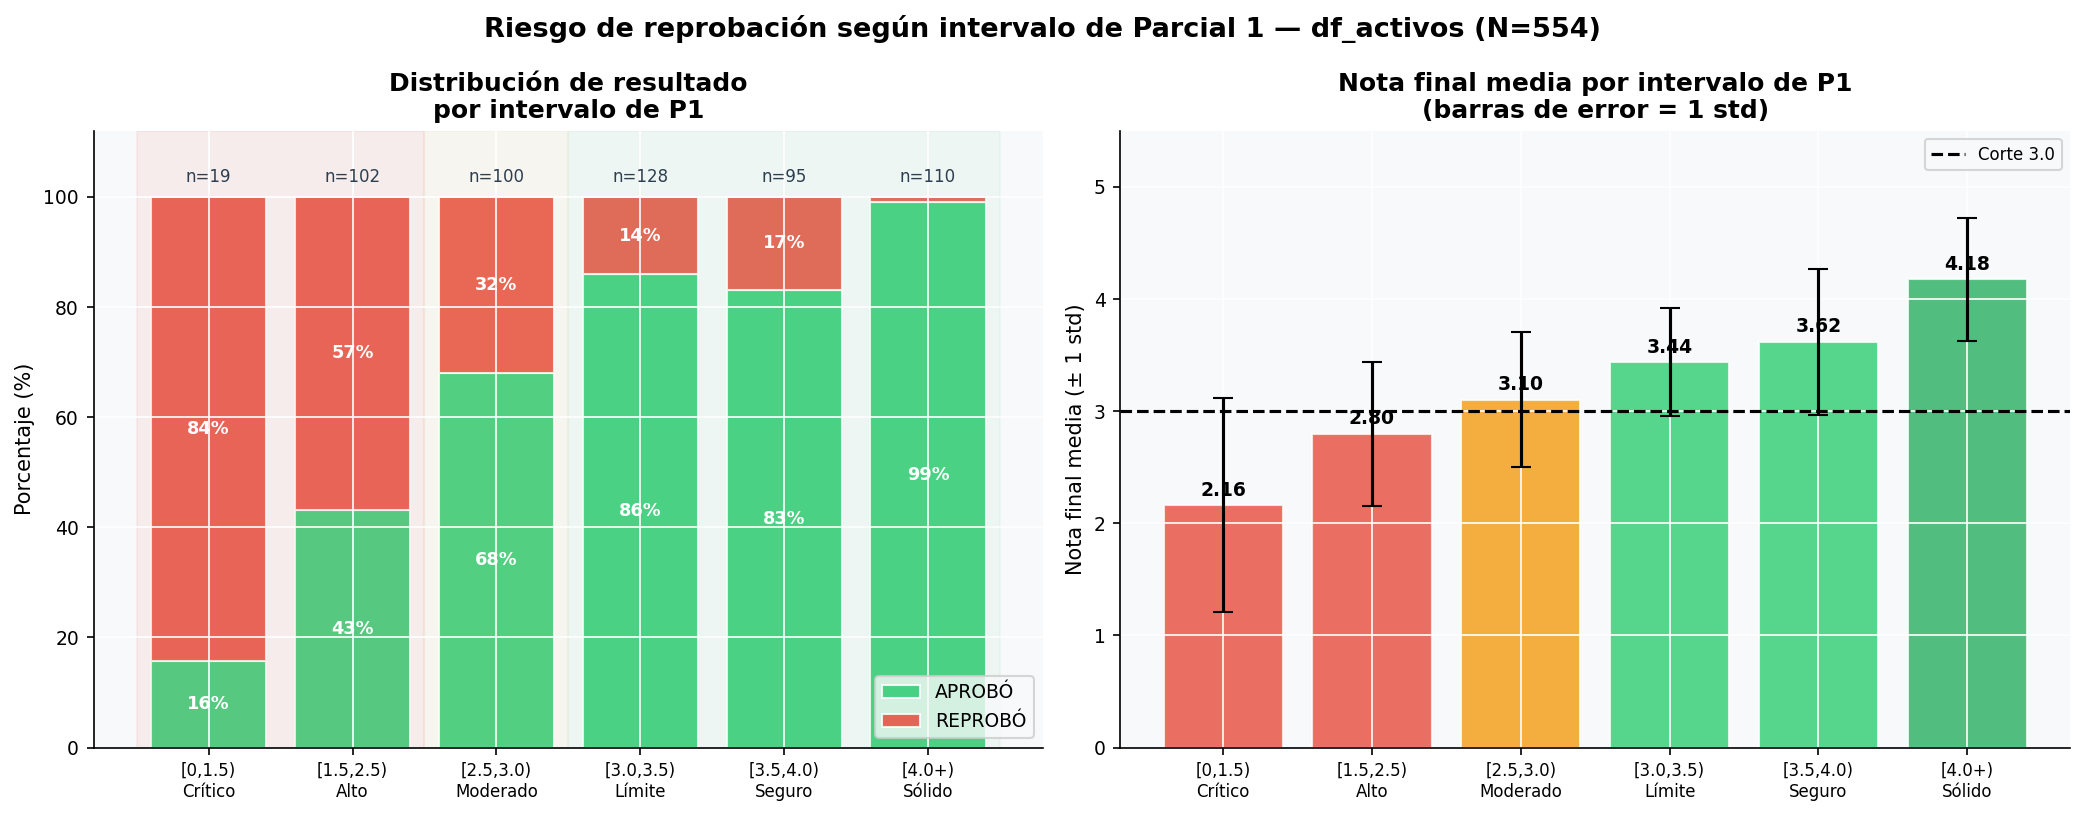

In [7]:
# ── Visualización de la tabla de riesgo ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Riesgo de reprobación según intervalo de Parcial 1 — df_activos (N=554)',
             fontsize=13, fontweight='bold')

labels_short = ['[0,1.5)\nCrítico', '[1.5,2.5)\nAlto', '[2.5,3.0)\nModerado',
                '[3.0,3.5)\nLímite', '[3.5,4.0)\nSeguro', '[4.0+)\nSólido']

p_apro = [tabla_pct.loc[l, 'APROBÓ']  * 100 if l in tabla_pct.index else 0 for l in labels]
p_repr = [tabla_pct.loc[l, 'REPROBÓ'] * 100 if l in tabla_pct.index else 0 for l in labels]
n_tot  = [tabla_abs.loc[l].sum() if l in tabla_abs.index else 0 for l in labels]
x      = np.arange(len(labels))

# ── Panel A: Barras apiladas 100% ─────────────────────────────────────────────
ax = axes[0]
ax.bar(x, p_apro, color=PALETA_ESTADO['APROBÓ'], alpha=0.85, label='APROBÓ', edgecolor='white')
ax.bar(x, p_repr, bottom=p_apro, color=PALETA_ESTADO['REPROBÓ'], alpha=0.85,
       label='REPROBÓ', edgecolor='white')
for i, (pa, pr, n) in enumerate(zip(p_apro, p_repr, n_tot)):
    if pa > 8: ax.text(i, pa/2, f'{pa:.0f}%', ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
    if pr > 8: ax.text(i, pa + pr/2, f'{pr:.0f}%', ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
    ax.text(i, 102, f'n={n}', ha='center', va='bottom', fontsize=8, color='#2c3e50')
ax.set_xticks(x); ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel('Porcentaje (%)'); ax.set_ylim(0, 112)
ax.set_title('Distribución de resultado\npor intervalo de P1', fontweight='bold')
ax.legend(loc='lower right')
ax.axvspan(-0.5, 1.5, alpha=0.07, color='#e74c3c')
ax.axvspan(1.5, 2.5,  alpha=0.04, color='#f39c12')
ax.axvspan(2.5, 5.5,  alpha=0.05, color='#2ecc71')

# ── Panel B: Nota final media por intervalo ───────────────────────────────────
ax2 = axes[1]
nota_m = [df_activos[df_activos['intervalo_p1'] == l]['nota_100'].mean() for l in labels]
nota_s = [df_activos[df_activos['intervalo_p1'] == l]['nota_100'].std()  for l in labels]
colores_barra = ['#e74c3c', '#e74c3c', '#f39c12', '#2ecc71', '#2ecc71', '#27ae60']

bars2 = ax2.bar(x, nota_m, color=colores_barra, alpha=0.8, edgecolor='white')
ax2.errorbar(x, nota_m, yerr=nota_s, fmt='none', color='black', capsize=5, linewidth=1.5)
for bar, m in zip(bars2, nota_m):
    if not np.isnan(m):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{m:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(3.0, color='black', linestyle='--', linewidth=1.5, label='Corte 3.0')
ax2.set_xticks(x); ax2.set_xticklabels(labels_short, fontsize=8)
ax2.set_ylabel('Nota final media (± 1 std)'); ax2.set_ylim(0, 5.5)
ax2.set_title('Nota final media por intervalo de P1\n(barras de error = 1 std)',
              fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_intervalos_p1_riesgo.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.4 Tabla de riesgo desagregada por era
La pregunta natural es si el mismo umbral de P1 tiene el mismo poder predictivo en el formato antiguo y en el nuevo. Un cambio en los umbrales implicaría que los modelos necesitan un tratamiento diferente por era.

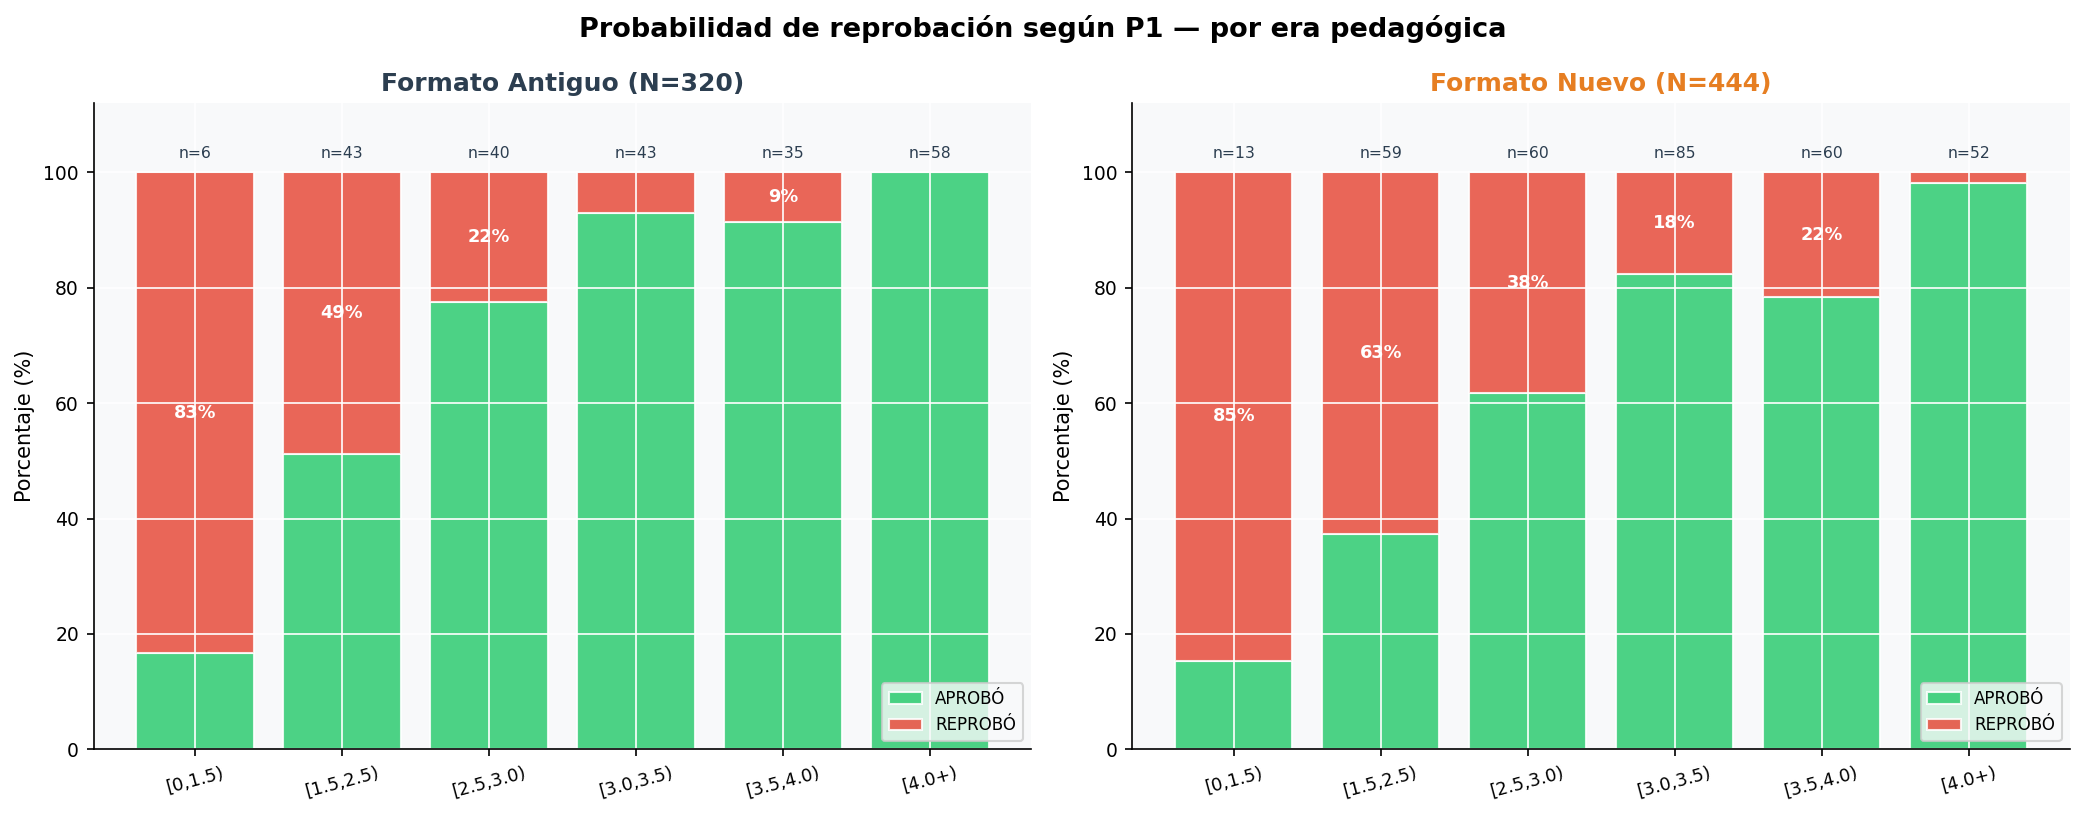

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Probabilidad de reprobación según P1 — por era pedagógica',
             fontsize=13, fontweight='bold')

bins_s   = [0, 1.5, 2.5, 3.0, 3.5, 4.0, 7.0]
labels_s = ['[0,1.5)', '[1.5,2.5)', '[2.5,3.0)', '[3.0,3.5)', '[3.5,4.0)', '[4.0+)']
eras     = ['formato_antiguo', 'formato_nuevo']
eras_lab = ['Formato Antiguo (N=320)', 'Formato Nuevo (N=444)']

for ax, era, era_label in zip(axes, eras, eras_lab):
    sub = df_activos[df_activos['era'] == era].copy()
    sub['int_p1'] = pd.cut(sub['parcial_1'], bins=bins_s, labels=labels_s, right=False)

    tbl     = pd.crosstab(sub['int_p1'], sub['estado'], normalize='index').reindex(labels_s)
    tbl_abs = pd.crosstab(sub['int_p1'], sub['estado']).reindex(labels_s).fillna(0)

    x   = np.arange(len(labels_s))
    p_ap = [tbl.loc[l, 'APROBÓ']  * 100 if l in tbl.index and 'APROBÓ'  in tbl.columns else 0 for l in labels_s]
    p_rp = [tbl.loc[l, 'REPROBÓ'] * 100 if l in tbl.index and 'REPROBÓ' in tbl.columns else 0 for l in labels_s]
    ns   = [tbl_abs.loc[l].sum() if l in tbl_abs.index else 0 for l in labels_s]

    ax.bar(x, p_ap, color=PALETA_ESTADO['APROBÓ'],  alpha=0.85, label='APROBÓ',  edgecolor='white')
    ax.bar(x, p_rp, bottom=p_ap, color=PALETA_ESTADO['REPROBÓ'], alpha=0.85,
           label='REPROBÓ', edgecolor='white')
    for i, (pa, pr, n) in enumerate(zip(p_ap, p_rp, ns)):
        if pr > 8: ax.text(i, pa + pr/2, f'{pr:.0f}%', ha='center', va='center',
                            fontsize=8.5, color='white', fontweight='bold')
        ax.text(i, 102, f'n={int(n)}', ha='center', va='bottom', fontsize=7.5, color='#2c3e50')

    ax.set_xticks(x); ax.set_xticklabels(labels_s, rotation=15, fontsize=8.5)
    ax.set_ylabel('Porcentaje (%)'); ax.set_ylim(0, 112)
    ax.set_title(f'{era_label}', fontweight='bold', color=PALETA_ERA[era])
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_intervalos_p1_por_era.png', bbox_inches='tight', dpi=150)
plt.show()

### Sección 3 — Evaluaciones Continuas: AMs, Quices y Talleres
Las evaluaciones continuas representan el 30% restante del curso y ofrecen señales más tempranas que los parciales (algunas disponibles antes del P1). Sin embargo, su estructura varía considerablemente entre eras y semestres.

Un dato relevante encontrado en el análisis: las AMs grupales (202420) e individuales (202510/202520) no muestran diferencia estadísticamente significativa en distribución de notas (Mann-Whitney p=0.54), aunque las individuales presentan mayor varianza. Esto es relevante porque sugiere que las AMs pueden tratarse como features comparables entre semestres del formato nuevo, aunque incluyendo modalidad como variable de control.
### 3.1 Distribuciones de AMs y quices por estado y era

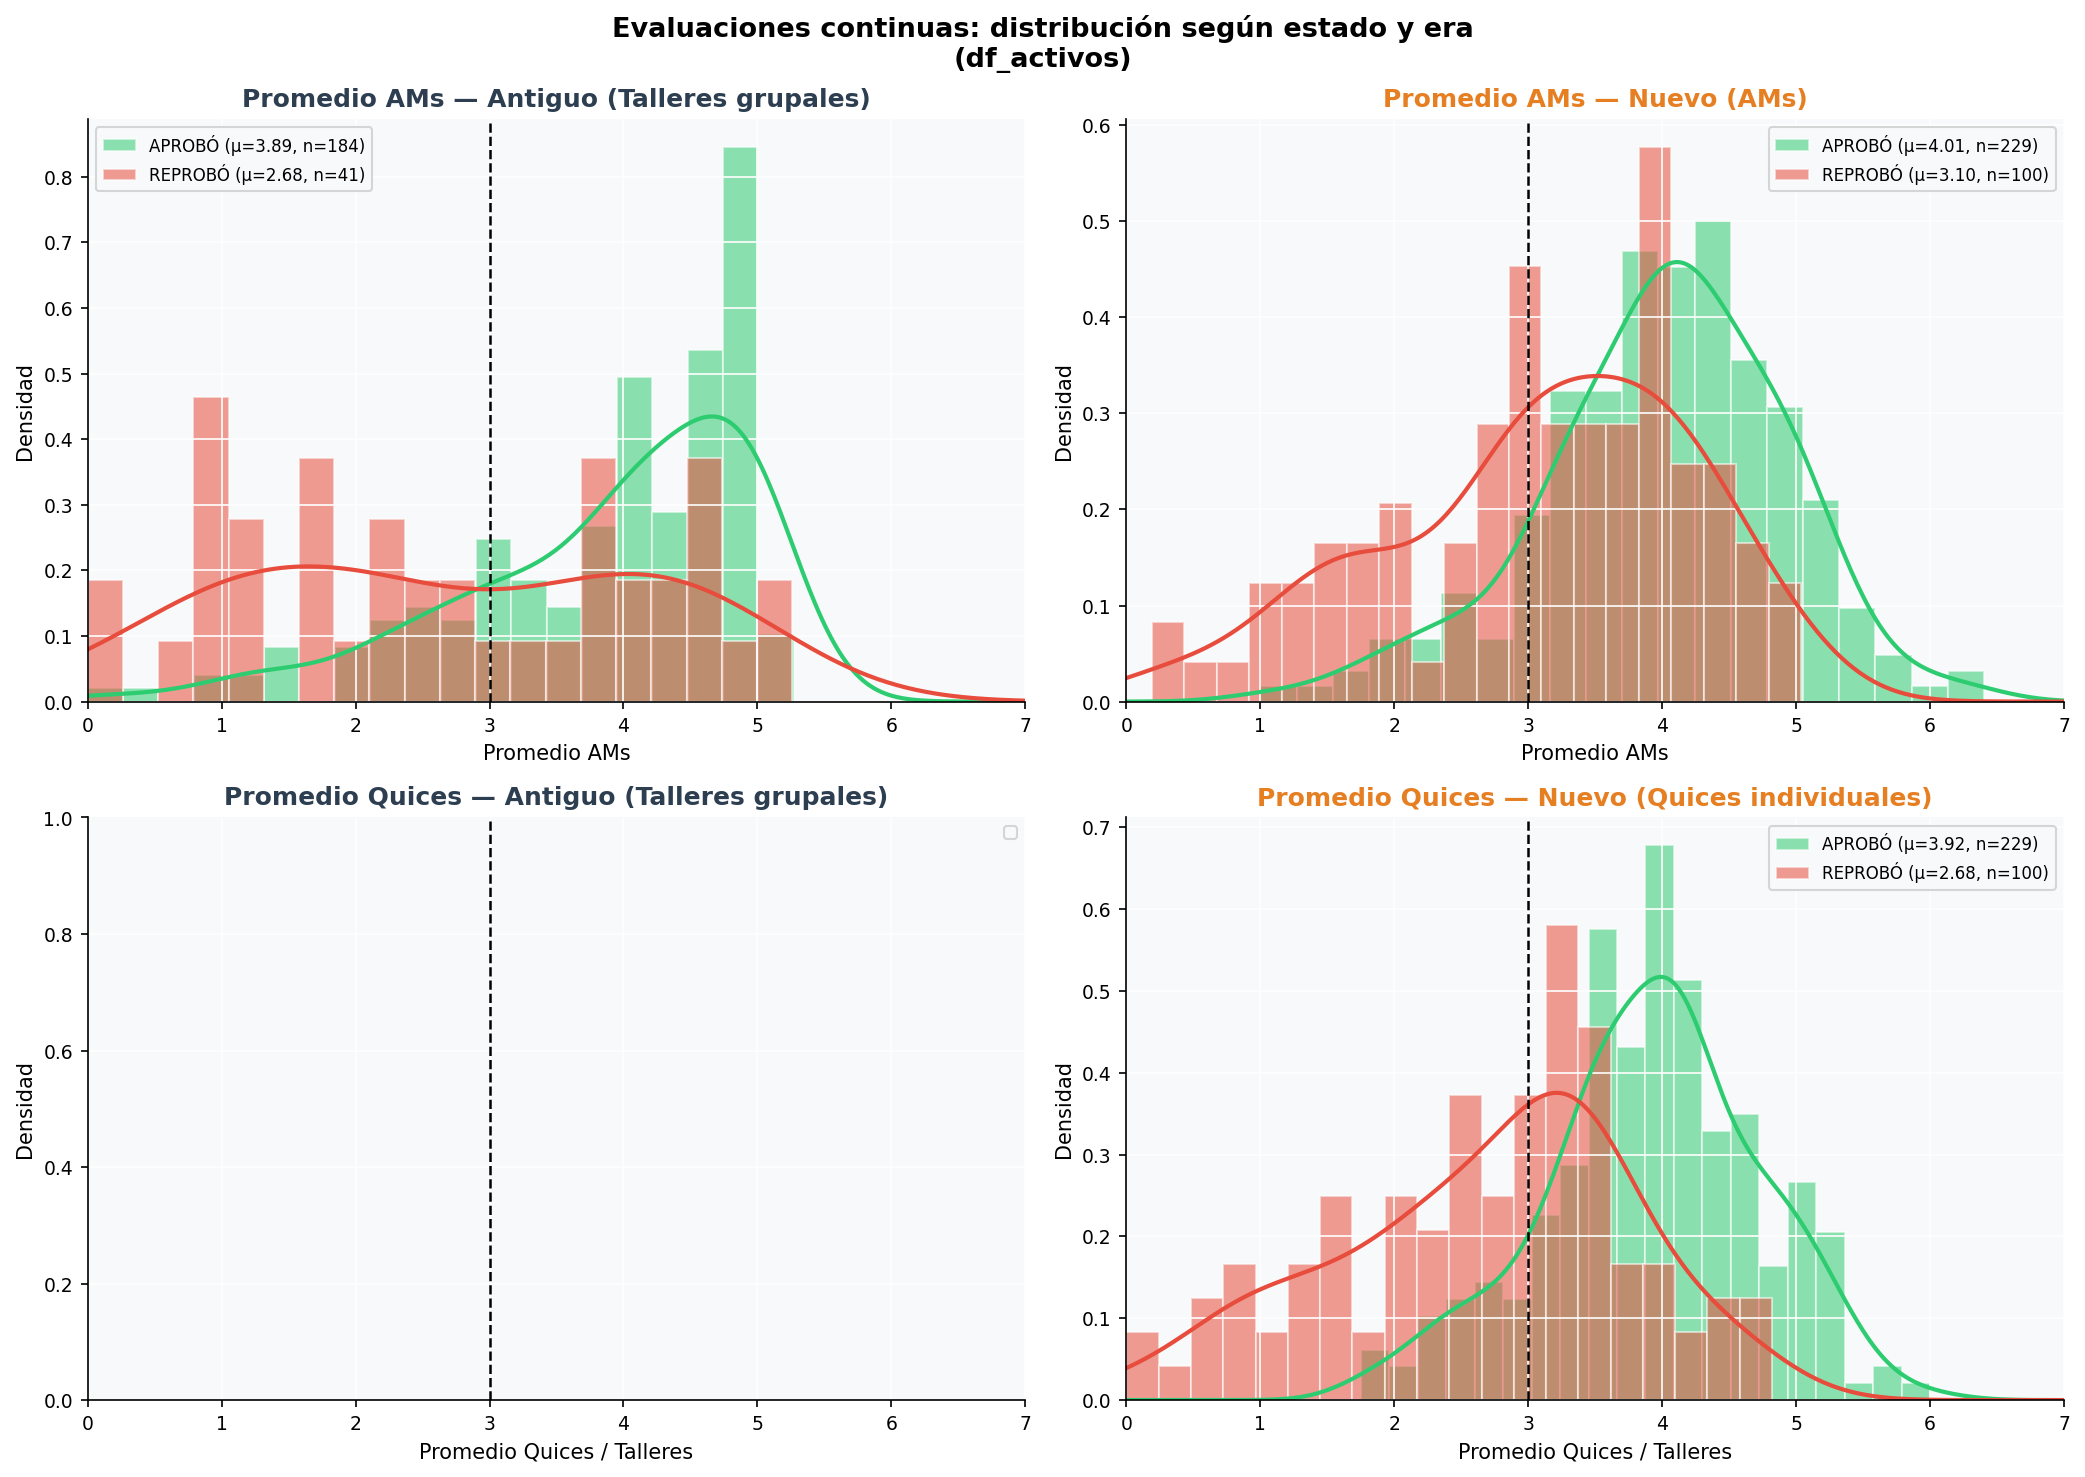

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evaluaciones continuas: distribución según estado y era\n(df_activos)',
             fontsize=13, fontweight='bold')

for col_idx, era in enumerate(['formato_antiguo', 'formato_nuevo']):
    sub       = df_activos[df_activos['era'] == era]
    era_label = 'Antiguo' if 'antiguo' in era else 'Nuevo'

    # ── Fila 1: promedio_ams ──────────────────────────────────────────────────
    ax = axes[0, col_idx]
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = sub[sub['estado'] == estado]['promedio_ams'].dropna()
        if len(data) < 5: continue
        ax.hist(data, bins=20, alpha=0.55, color=PALETA_ESTADO[estado],
                label=f'{estado} (μ={data.mean():.2f}, n={len(data)})',
                edgecolor='white', density=True)
        if len(data) > 5:
            kde_x = np.linspace(0, 7, 300)
            ax.plot(kde_x, gaussian_kde(data)(kde_x), color=PALETA_ESTADO[estado], linewidth=2)

    ax.axvline(3.0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Promedio AMs'); ax.set_ylabel('Densidad'); ax.set_xlim(0, 7)
    nota_var = 'Talleres grupales' if 'antiguo' in era else 'AMs'
    ax.set_title(f'Promedio AMs — {era_label} ({nota_var})',
                 fontweight='bold', color=PALETA_ERA[era])
    ax.legend(fontsize=8)

    # ── Fila 2: promedio_quices ───────────────────────────────────────────────
    ax2 = axes[1, col_idx]
    for estado in ['APROBÓ', 'REPROBÓ']:
        data = sub[sub['estado'] == estado]['promedio_quices'].dropna()
        if len(data) < 5: continue
        ax2.hist(data, bins=20, alpha=0.55, color=PALETA_ESTADO[estado],
                 label=f'{estado} (μ={data.mean():.2f}, n={len(data)})',
                 edgecolor='white', density=True)
        if len(data) > 5:
            kde_x = np.linspace(0, 7, 300)
            ax2.plot(kde_x, gaussian_kde(data)(kde_x), color=PALETA_ESTADO[estado], linewidth=2)

    ax2.axvline(3.0, color='black', linestyle='--', linewidth=1.2)
    ax2.set_xlabel('Promedio Quices / Talleres'); ax2.set_ylabel('Densidad'); ax2.set_xlim(0, 7)
    quiz_var = 'Talleres grupales' if 'antiguo' in era else 'Quices individuales'
    ax2.set_title(f'Promedio Quices — {era_label} ({quiz_var})',
                  fontweight='bold', color=PALETA_ERA[era])
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_evaluaciones_continuas_por_era.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Evolución intra-semestre de AMs y quices
La evolución de las medias de AMs y quices a lo largo del semestre revela dinámicas propias del formato nuevo. Una caída en las medias de las AMs hacia el final del semestre (especialmente observable en 202510 con AM5=2.28 y en 202420 con AM6=2.57) puede interpretarse como señal de desenganche antes del P3.

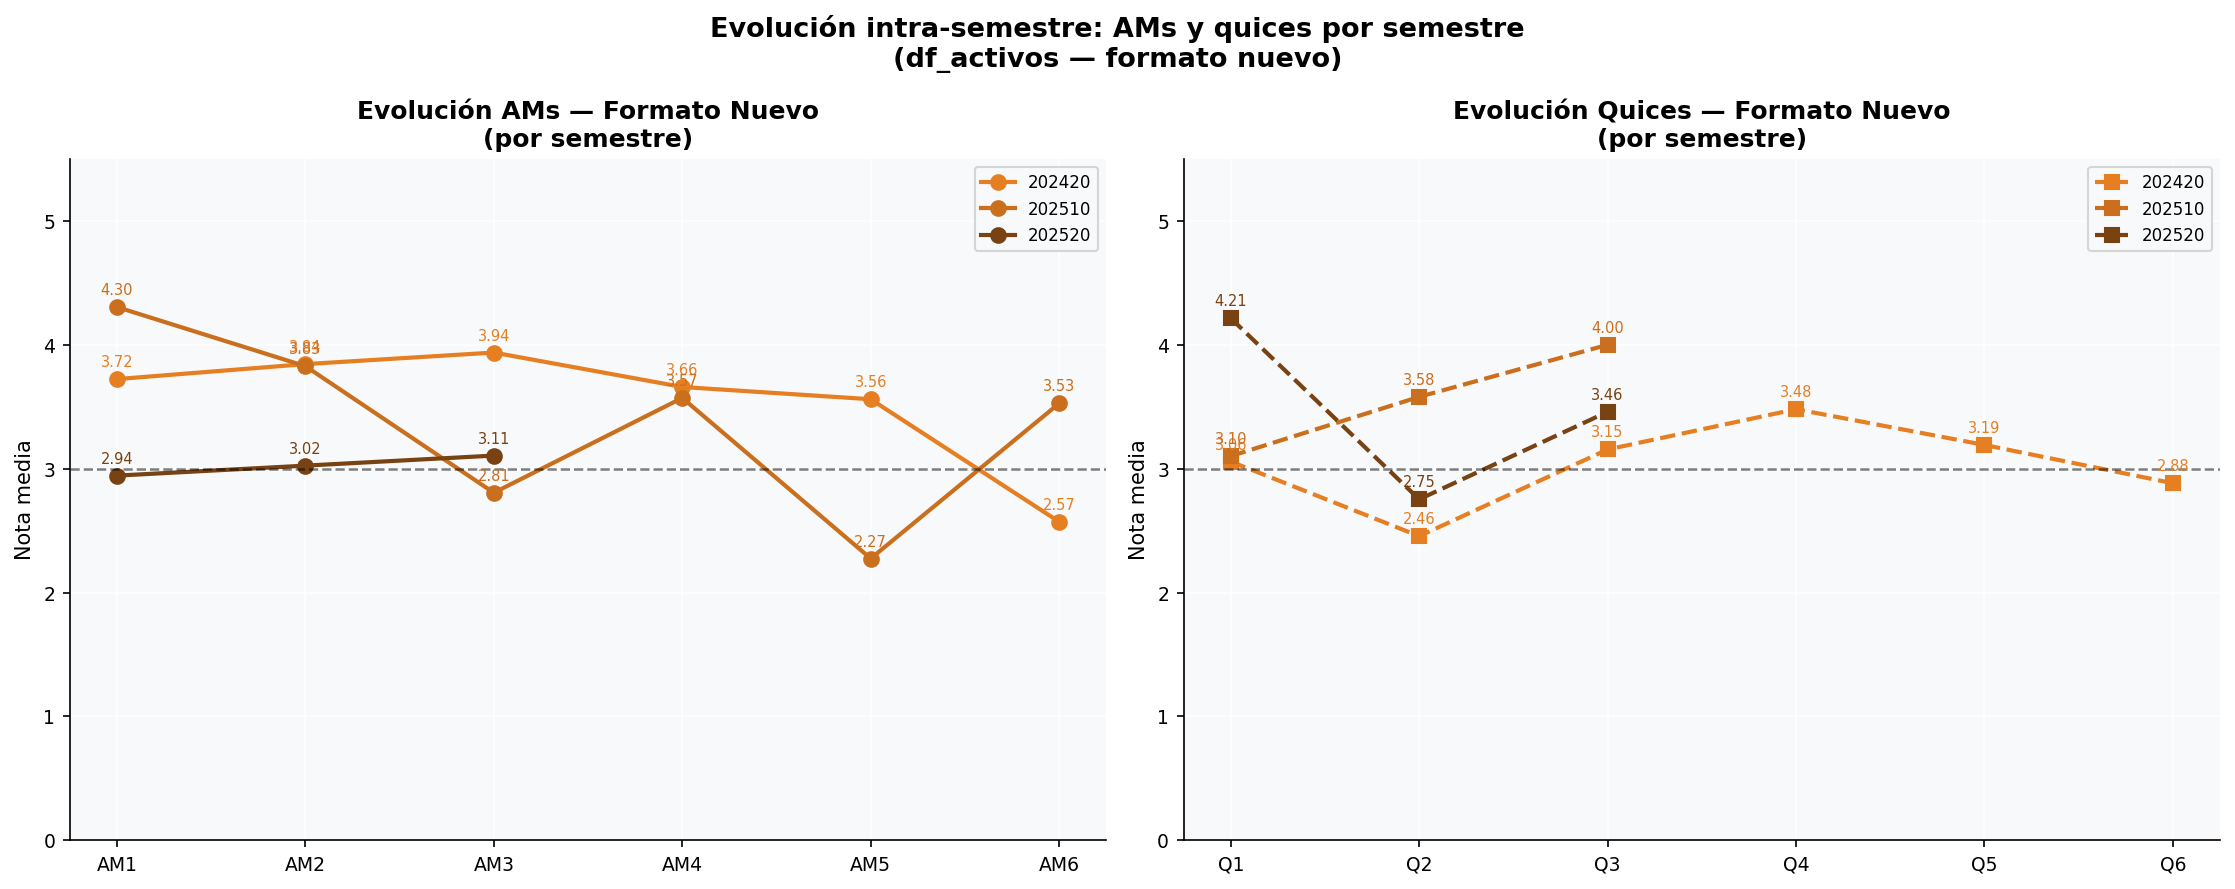

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Evolución intra-semestre: AMs y quices por semestre\n(df_activos — formato nuevo)',
             fontsize=13, fontweight='bold')

# ── AMs ──────────────────────────────────────────────────────────────────────
ax = axes[0]
sem_ams = {
    202420: ['am_1','am_2','am_3','am_4','am_5','am_6'],
    202510: ['am_1','am_2','am_3','am_4','am_5','am_6'],
    202520: ['am_1','am_2','am_3'],
}
for sem, ams in sem_ams.items():
    sub    = df_activos[df_activos['semestre'] == sem]
    medias = [sub[a].mean() for a in ams]
    ax.plot(range(len(ams)), medias, 'o-', color=PALETA_SEMESTRE[sem],
            linewidth=2, markersize=7, label=str(sem))
    for i, m in enumerate(medias):
        ax.annotate(f'{m:.2f}', (i, m), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=7, color=PALETA_SEMESTRE[sem])

ax.axhline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax.set_xticks(range(6)); ax.set_xticklabels(['AM1','AM2','AM3','AM4','AM5','AM6'])
ax.set_ylabel('Nota media'); ax.set_ylim(0, 5.5)
ax.set_title('Evolución AMs — Formato Nuevo\n(por semestre)', fontweight='bold')
ax.legend(fontsize=8)

# ── Quices ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
sem_quiz = {
    202420: ['quiz_1','quiz_2','quiz_3','quiz_4','quiz_5','quiz_6'],
    202510: ['quiz_1','quiz_2','quiz_3'],
    202520: ['quiz_1','quiz_2','quiz_3'],
}
for sem, quices in sem_quiz.items():
    sub    = df_activos[df_activos['semestre'] == sem]
    medias = [sub[q].mean() for q in quices]
    ax2.plot(range(len(quices)), medias, 's--', color=PALETA_SEMESTRE[sem],
             linewidth=2, markersize=7, label=str(sem))
    for i, m in enumerate(medias):
        ax2.annotate(f'{m:.2f}', (i, m), textcoords='offset points',
                     xytext=(0, 6), ha='center', fontsize=7, color=PALETA_SEMESTRE[sem])

ax2.axhline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.set_xticks(range(6)); ax2.set_xticklabels(['Q1','Q2','Q3','Q4','Q5','Q6'])
ax2.set_ylabel('Nota media'); ax2.set_ylim(0, 5.5)
ax2.set_title('Evolución Quices — Formato Nuevo\n(por semestre)', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_evolucion_ams_quices.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Modalidad grupal vs. individual en AMs — prueba estadística

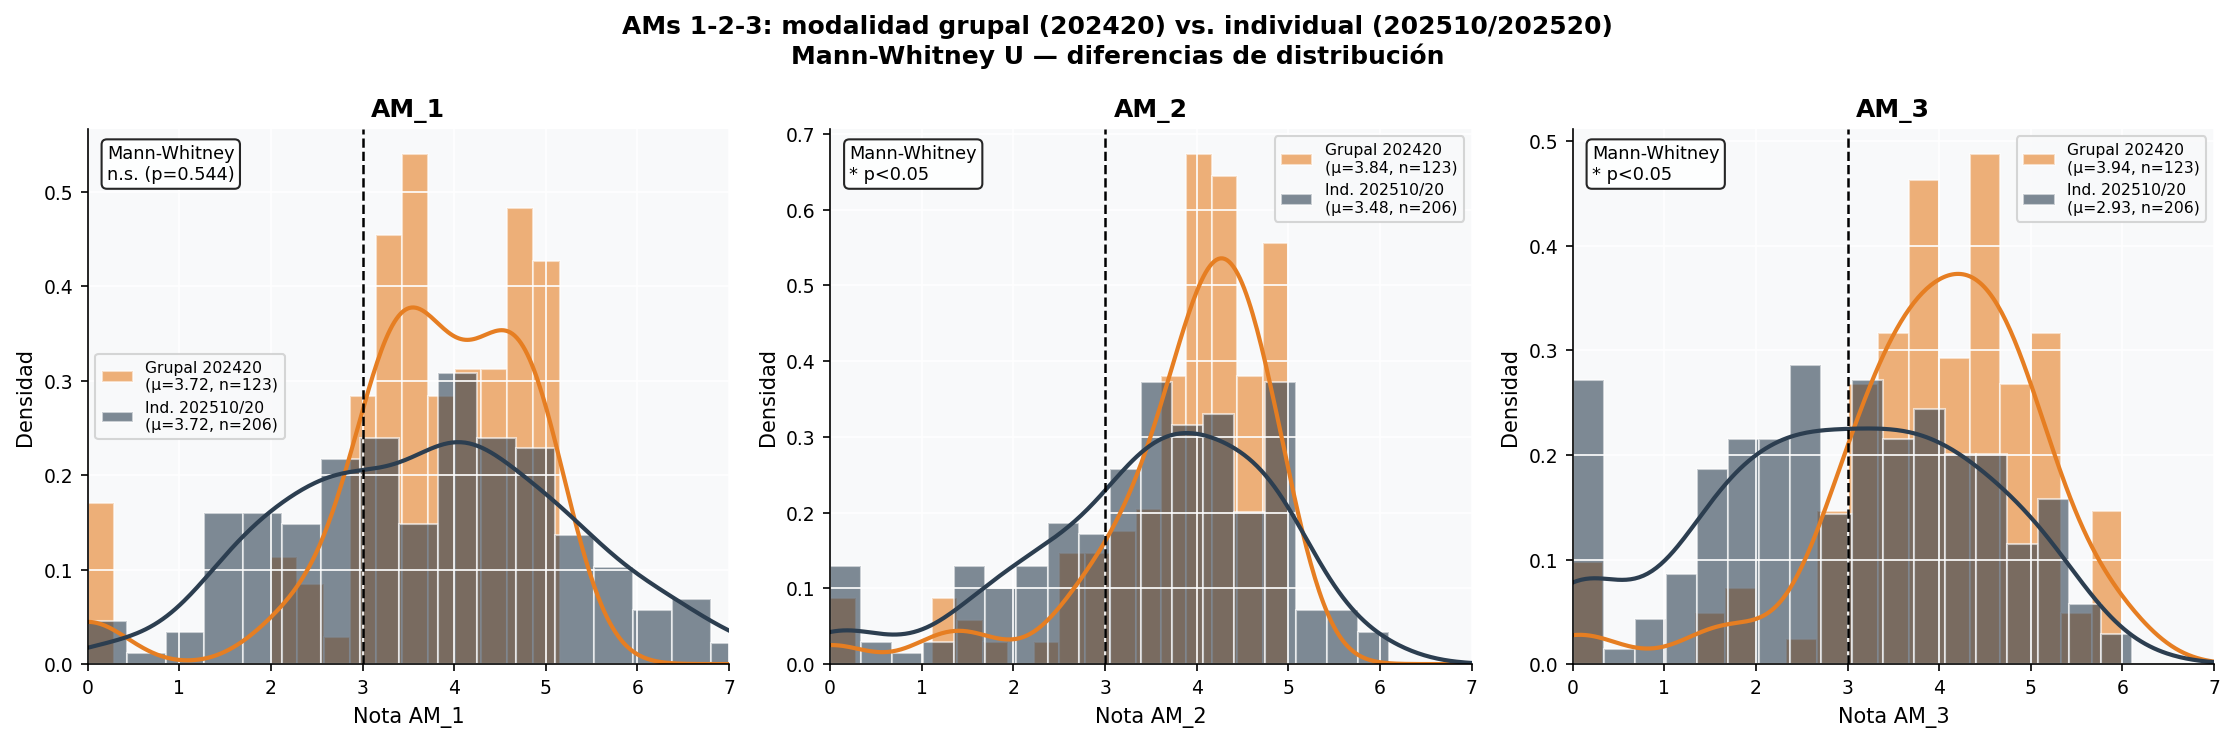


Resultado: p>0.05 — las distribuciones de AMs grupales e individuales
no difieren significativamente en magnitud, pero sí en varianza.
Implicación para el modelado: incluir 'modalidad' como variable de control.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('AMs 1-2-3: modalidad grupal (202420) vs. individual (202510/202520)\n'
             'Mann-Whitney U — diferencias de distribución',
             fontsize=12, fontweight='bold')

for i, am in enumerate(['am_1', 'am_2', 'am_3']):
    ax    = axes[i]
    data_g = df_activos[df_activos['semestre'] == 202420][am].dropna()
    data_i = df_activos[df_activos['semestre'].isin([202510, 202520])][am].dropna()

    ax.hist(data_g, bins=18, alpha=0.6, color='#e67e22',
            label=f'Grupal 202420\n(μ={data_g.mean():.2f}, n={len(data_g)})',
            edgecolor='white', density=True)
    ax.hist(data_i, bins=18, alpha=0.6, color='#2c3e50',
            label=f'Ind. 202510/20\n(μ={data_i.mean():.2f}, n={len(data_i)})',
            edgecolor='white', density=True)
    for data, color in [(data_g, '#e67e22'), (data_i, '#2c3e50')]:
        if len(data) > 5:
            kde_x = np.linspace(0, 7, 300)
            ax.plot(kde_x, gaussian_kde(data)(kde_x), color=color, linewidth=2)

    u_stat, p_val = mannwhitneyu(data_g, data_i, alternative='two-sided')
    sig = '* p<0.05' if p_val < 0.05 else f'n.s. (p={p_val:.3f})'
    ax.text(0.03, 0.97, f'Mann-Whitney\n{sig}',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.axvline(3.0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel(f'Nota {am.upper()}'); ax.set_ylabel('Densidad')
    ax.set_xlim(0, 7); ax.set_title(f'{am.upper()}', fontweight='bold')
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('../figures/02_modalidad_ams_estadistico.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nResultado: p>0.05 — las distribuciones de AMs grupales e individuales")
print("no difieren significativamente en magnitud, pero sí en varianza.")
print("Implicación para el modelado: incluir 'modalidad' como variable de control.")

## Sección 4 — Trayectorias $P_1 \rightarrow P_2 \rightarrow P_3$

Esta sección analiza las **trayectorias individuales** de los estudiantes a lo largo del semestre. Más allá de las notas puntuales, el patrón de cambio entre parciales puede revelar información predictiva adicional.

Los patrones se clasifican con un umbral de **$\pm0.5$ puntos** entre parciales consecutivos:

| Patrón | Criterio | N total | % REPROBÓ |
| :--- | :--- | :--- | :--- |
| **Estable** | Variaciones $< \pm0.5$ en ambas transiciones | 306 (55%) | 26% |
| **Pico intermedio** | $P_2 \uparrow \ge 0.5$, $P_3 \downarrow \ge 0.5$ | 129 (23%) | 23% |
| **Recuperación** | $P_2 \downarrow \ge 0.5$, $P_3 \uparrow \ge 0.5$ | 57 (10%) | 18% |
| **Declive sostenido** | Ambas transiciones bajan $\ge 0.5$ | 40 (7%) | 45% |
| **Mejora sostenida** | Ambas transiciones suben $\ge 0.5$ | 22 (4%) | 9% |

---

### Observaciones clave:

* **Riesgo Máximo:** El **declive sostenido** tiene la tasa de reprobación más alta (**45%**), triplicando la tasa base.
* **Ventana de Observación:** Este patrón solo es visible a partir del **Checkpoint 2 (semana 11)**, momento en el cual ya se dispone del dato de $P_2$.
### 4.1 Clasificación y distribución de patrones

In [12]:
# ── Clasificar patrones ───────────────────────────────────────────────────────
df_activos['delta_p2_p1'] = df_activos['parcial_2'] - df_activos['parcial_1']
df_activos['delta_p3_p2'] = df_activos['parcial_3'] - df_activos['parcial_2']

umbral = 0.5
def clasificar_patron(row):
    d1, d2 = row['delta_p2_p1'], row['delta_p3_p2']
    if   d1 >=  umbral and d2 >=  umbral: return 'Mejora sostenida'
    elif d1 <= -umbral and d2 <= -umbral: return 'Declive sostenido'
    elif d1 <= -umbral and d2 >=  umbral: return 'Recuperación'
    elif d1 >=  umbral and d2 <= -umbral: return 'Pico intermedio'
    else:                                 return 'Estable'

df_activos['patron'] = df_activos.apply(clasificar_patron, axis=1)

tabla_patron     = pd.crosstab(df_activos['patron'], df_activos['estado'])
tabla_patron_pct = pd.crosstab(df_activos['patron'], df_activos['estado'],
                                normalize='index').round(3)
tabla_patron['Total'] = tabla_patron.sum(axis=1)

print("DISTRIBUCIÓN DE PATRONES DE TRAYECTORIA POR ESTADO:")
print(tabla_patron.to_string())
print("\nProporciones dentro de cada patrón:")
print(tabla_patron_pct.to_string())

DISTRIBUCIÓN DE PATRONES DE TRAYECTORIA POR ESTADO:
estado             APROBÓ  REPROBÓ  Total
patron                                   
Declive sostenido      22       18     40
Estable               225       81    306
Mejora sostenida       20        2     22
Pico intermedio        99       30    129
Recuperación           47       10     57

Proporciones dentro de cada patrón:
estado             APROBÓ  REPROBÓ
patron                            
Declive sostenido   0.550    0.450
Estable             0.735    0.265
Mejora sostenida    0.909    0.091
Pico intermedio     0.767    0.233
Recuperación        0.825    0.175


### 4.2 Visualización de patrones: riesgo, nota media y trayectorias individuales

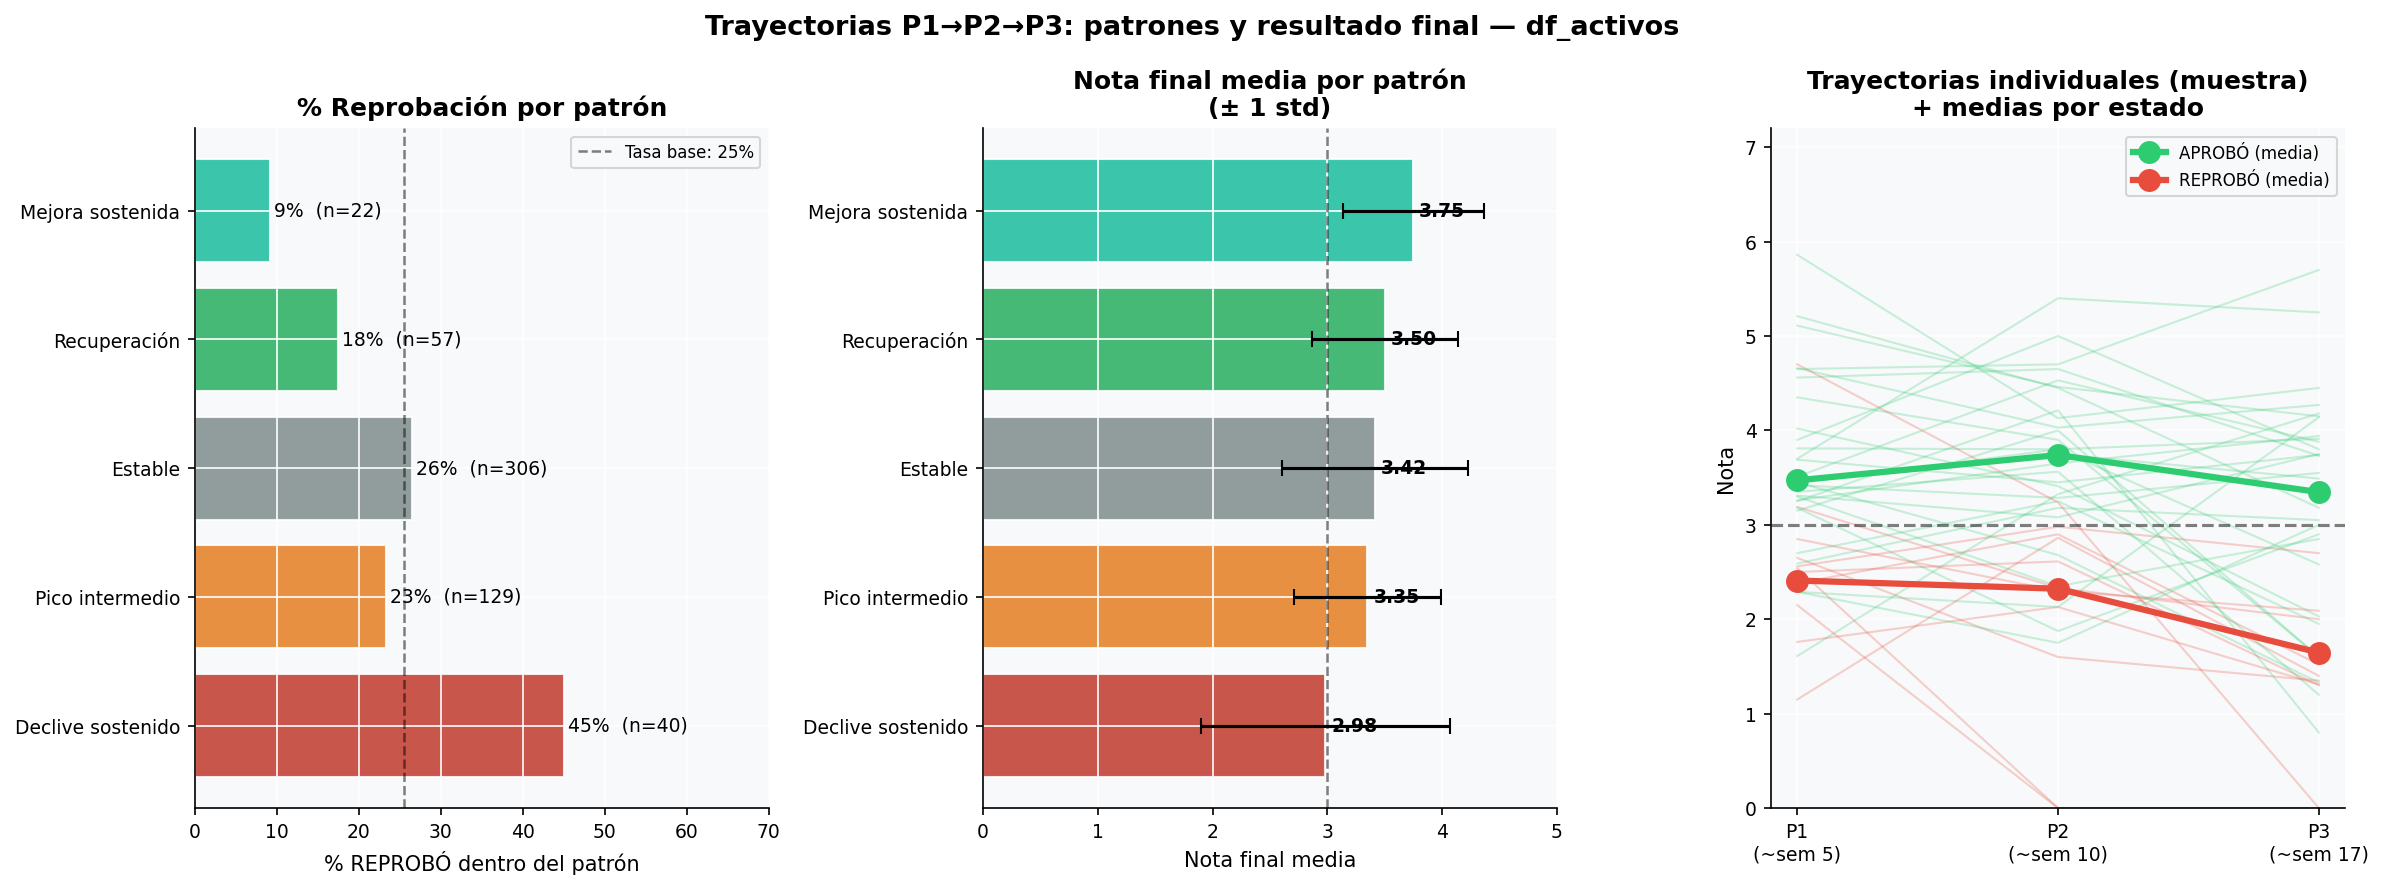

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Trayectorias P1→P2→P3: patrones y resultado final — df_activos',
             fontsize=13, fontweight='bold')

orden_patron = ['Declive sostenido', 'Pico intermedio', 'Estable',
                'Recuperación', 'Mejora sostenida']
colores_patron = {
    'Declive sostenido': '#c0392b',
    'Pico intermedio':   '#e67e22',
    'Estable':           '#7f8c8d',
    'Recuperación':      '#27ae60',
    'Mejora sostenida':  '#1abc9c',
}

# ── Panel A: % REPROBÓ horizontal por patrón ─────────────────────────────────
ax = axes[0]
pct_repr = [
    tabla_patron_pct.loc[p, 'REPROBÓ'] * 100
    if p in tabla_patron_pct.index and 'REPROBÓ' in tabla_patron_pct.columns else 0
    for p in orden_patron
]
n_patron = [tabla_patron.loc[p, 'Total'] if p in tabla_patron.index else 0
            for p in orden_patron]

bars = ax.barh(range(len(orden_patron)), pct_repr,
               color=[colores_patron[p] for p in orden_patron], alpha=0.85, edgecolor='white')
for i, (bar, v, n) in enumerate(zip(bars, pct_repr, n_patron)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.0f}%  (n={int(n)})', va='center', fontsize=9)

ax.set_yticks(range(len(orden_patron)))
ax.set_yticklabels(orden_patron, fontsize=9)
ax.set_xlabel('% REPROBÓ dentro del patrón'); ax.set_xlim(0, 70)
ax.axvline(141/554*100, color='black', linestyle='--', linewidth=1.2,
           alpha=0.5, label=f'Tasa base: {141/554*100:.0f}%')
ax.set_title('% Reprobación por patrón', fontweight='bold')
ax.legend(fontsize=8)

# ── Panel B: Nota final media por patrón ─────────────────────────────────────
ax2 = axes[1]
nota_m = [df_activos[df_activos['patron'] == p]['nota_100'].mean() for p in orden_patron]
nota_s = [df_activos[df_activos['patron'] == p]['nota_100'].std()  for p in orden_patron]

bars2 = ax2.barh(range(len(orden_patron)), nota_m,
                  color=[colores_patron[p] for p in orden_patron], alpha=0.85, edgecolor='white')
ax2.errorbar(nota_m, range(len(orden_patron)), xerr=nota_s,
             fmt='none', color='black', capsize=4, linewidth=1.5)
for i, (bar, m) in enumerate(zip(bars2, nota_m)):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{m:.2f}', va='center', fontsize=9, fontweight='bold')
ax2.set_yticks(range(len(orden_patron))); ax2.set_yticklabels(orden_patron, fontsize=9)
ax2.set_xlabel('Nota final media'); ax2.axvline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax2.set_xlim(0, 5); ax2.set_title('Nota final media por patrón\n(± 1 std)', fontweight='bold')

# ── Panel C: Trayectorias individuales + medias ───────────────────────────────
ax3 = axes[2]
muestra = df_activos.sample(n=min(40, len(df_activos)), random_state=42)
for _, row in muestra.iterrows():
    vals = [row['parcial_1'], row['parcial_2'], row['parcial_3']]
    ax3.plot(range(3), vals, alpha=0.25, linewidth=1,
             color=PALETA_ESTADO[row['estado']])

for estado in ['APROBÓ', 'REPROBÓ']:
    sub    = df_activos[df_activos['estado'] == estado]
    medias = [sub[p].mean() for p in ['parcial_1', 'parcial_2', 'parcial_3']]
    ax3.plot(range(3), medias, 'o-', color=PALETA_ESTADO[estado],
             linewidth=3, markersize=10, label=f'{estado} (media)', zorder=5)

ax3.axhline(3.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax3.set_xticks(range(3)); ax3.set_xticklabels(['P1\n(~sem 5)', 'P2\n(~sem 10)', 'P3\n(~sem 17)'])
ax3.set_ylabel('Nota'); ax3.set_ylim(0, 7.2)
ax3.set_title('Trayectorias individuales (muestra)\n+ medias por estado', fontweight='bold')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/02_trayectorias_parciales.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3 Casos especiales: recuperación y caída inesperada
Cuantificar los casos en que P1 "se equivoca" — estudiantes que fallan P1 pero aprueban, o aprueban P1 pero terminan reprobando — permite calibrar la sensibilidad y especificidad esperadas del Checkpoint 1.


In [14]:
print("=" * 70)
print("ANÁLISIS DE CASOS EXTREMOS — FALSOS POSITIVOS Y NEGATIVOS DEL CP1")
print("=" * 70)

# Falsos positivos: P1 < 3.0 pero APROBÓ al final
bajo_p1_apro  = df_activos[(df_activos['parcial_1'] < 3.0) & (df_activos['estado'] == 'APROBÓ')]
bajo_p1_total = df_activos[df_activos['parcial_1'] < 3.0]

print(f"\n✓ P1 < 3.0 y al final APROBÓ (recuperaciones): {len(bajo_p1_apro)}/{len(bajo_p1_total)} "
      f"({len(bajo_p1_apro)/len(bajo_p1_total)*100:.1f}%)")
print(f"  Media P2 en este grupo: {bajo_p1_apro['parcial_2'].mean():.3f}")
print(f"  Media P3 en este grupo: {bajo_p1_apro['parcial_3'].mean():.3f}")
print(f"  Media nota final:       {bajo_p1_apro['nota_100'].mean():.3f}")
print(f"  Por semestre:")
print(bajo_p1_apro.groupby('semestre').size().rename('N recuperaciones').to_string())

# Falsos negativos: P1 >= 3.0 pero REPROBÓ
alto_p1_repr  = df_activos[(df_activos['parcial_1'] >= 3.0) & (df_activos['estado'] == 'REPROBÓ')]
alto_p1_total = df_activos[df_activos['parcial_1'] >= 3.0]

print(f"\n✗ P1 ≥ 3.0 y al final REPROBÓ (caídas inesperadas): {len(alto_p1_repr)}/{len(alto_p1_total)} "
      f"({len(alto_p1_repr)/len(alto_p1_total)*100:.1f}%)")
print(f"  Media P2 en este grupo: {alto_p1_repr['parcial_2'].mean():.3f}")
print(f"  Media P3 en este grupo: {alto_p1_repr['parcial_3'].mean():.3f}")
print(f"  Media nota final:       {alto_p1_repr['nota_100'].mean():.3f}")
print(f"  Por semestre:")
print(alto_p1_repr.groupby('semestre').size().rename('N caídas').to_string())

print(f"\n── Implicaciones para el sistema de alertas ────────────────────────")
print(f"  CP1 basado en P1 < 3.0 alertará al {len(bajo_p1_total)/len(df_activos)*100:.0f}% de activos")
print(f"  De ellos, ~{len(bajo_p1_apro)/len(bajo_p1_total)*100:.0f}% terminará aprobando → falsos positivos")
print(f"  El {len(alto_p1_repr)/len(alto_p1_total)*100:.0f}% con P1 ≥ 3.0 aún reprobará → falsos negativos")
print(f"  El engagement (NB03) puede ayudar a discriminar ambos grupos")

ANÁLISIS DE CASOS EXTREMOS — FALSOS POSITIVOS Y NEGATIVOS DEL CP1

✓ P1 < 3.0 y al final APROBÓ (recuperaciones): 115/221 (52.0%)
  Media P2 en este grupo: 3.461
  Media P3 en este grupo: 3.223
  Media nota final:       3.375
  Por semestre:
semestre
202320    33
202410    21
202420    27
202510     8
202520    26

✗ P1 ≥ 3.0 y al final REPROBÓ (caídas inesperadas): 35/333 (10.5%)
  Media P2 en este grupo: 2.397
  Media P3 en este grupo: 1.724
  Media nota final:       2.644
  Por semestre:
semestre
202320     4
202410     2
202420     5
202510    19
202520     5

── Implicaciones para el sistema de alertas ────────────────────────
  CP1 basado en P1 < 3.0 alertará al 40% de activos
  De ellos, ~52% terminará aprobando → falsos positivos
  El 11% con P1 ≥ 3.0 aún reprobará → falsos negativos
  El engagement (NB03) puede ayudar a discriminar ambos grupos


### Sección 5 — Tabla Maestra y Resumen Visual

In [15]:
# ── Tabla maestra de estadísticos por semestre ────────────────────────────────
print("=" * 100)
print("TABLA MAESTRA: ESTADÍSTICOS DE NOTAS POR SEMESTRE (df_activos)")
print("=" * 100)

rows = []
for sem in semestres:
    sub = df_activos[df_activos['semestre'] == sem]
    era = 'Antiguo' if 'antiguo' in sub['era'].iloc[0] else 'Nuevo'
    rows.append({
        'Semestre':       sem,
        'Era':            era,
        'N':              len(sub),
        'N_aprobó':       (sub['estado']=='APROBÓ').sum(),
        'N_reprobó':      (sub['estado']=='REPROBÓ').sum(),
        'Tasa_aprobación':f"{(sub['estado']=='APROBÓ').mean()*100:.1f}%",
        'Nota_media':     round(sub['nota_100'].mean(), 3),
        'Nota_std':       round(sub['nota_100'].std(), 3),
        'P1_media':       round(sub['parcial_1'].mean(), 3),
        'P1_std':         round(sub['parcial_1'].std(), 3),
        'P2_media':       round(sub['parcial_2'].mean(), 3),
        'P3_media':       round(sub['parcial_3'].mean(), 3),
        'prom_ams':       round(sub['promedio_ams'].mean(), 3) if sub['promedio_ams'].notna().any() else '—',
        'prom_quiz':      round(sub['promedio_quices'].mean(), 3) if sub['promedio_quices'].notna().any() else '—',
    })

df_tabla = pd.DataFrame(rows)
print(df_tabla.to_string(index=False))

TABLA MAESTRA: ESTADÍSTICOS DE NOTAS POR SEMESTRE (df_activos)
 Semestre     Era   N  N_aprobó  N_reprobó Tasa_aprobación  Nota_media  Nota_std  P1_media  P1_std  P2_media  P3_media  prom_ams prom_quiz
   202320 Antiguo 143       116         27           81.1%       3.550     0.745     3.398   1.179     2.945     3.302     3.572         —
   202410 Antiguo  82        68         14           82.9%       3.508     0.745     3.211   0.927     3.158     3.093     3.841         —
   202420   Nuevo 123        90         33           73.2%       3.364     0.731     3.051   0.842     3.590     2.985     3.830     3.572
   202510   Nuevo 117        70         47           59.8%       3.047     0.701     3.262   0.904     3.177     1.769     4.164      3.56
   202520   Nuevo  89        69         20           77.5%       3.524     0.921     3.005   0.831     4.254     3.534     3.024     3.475


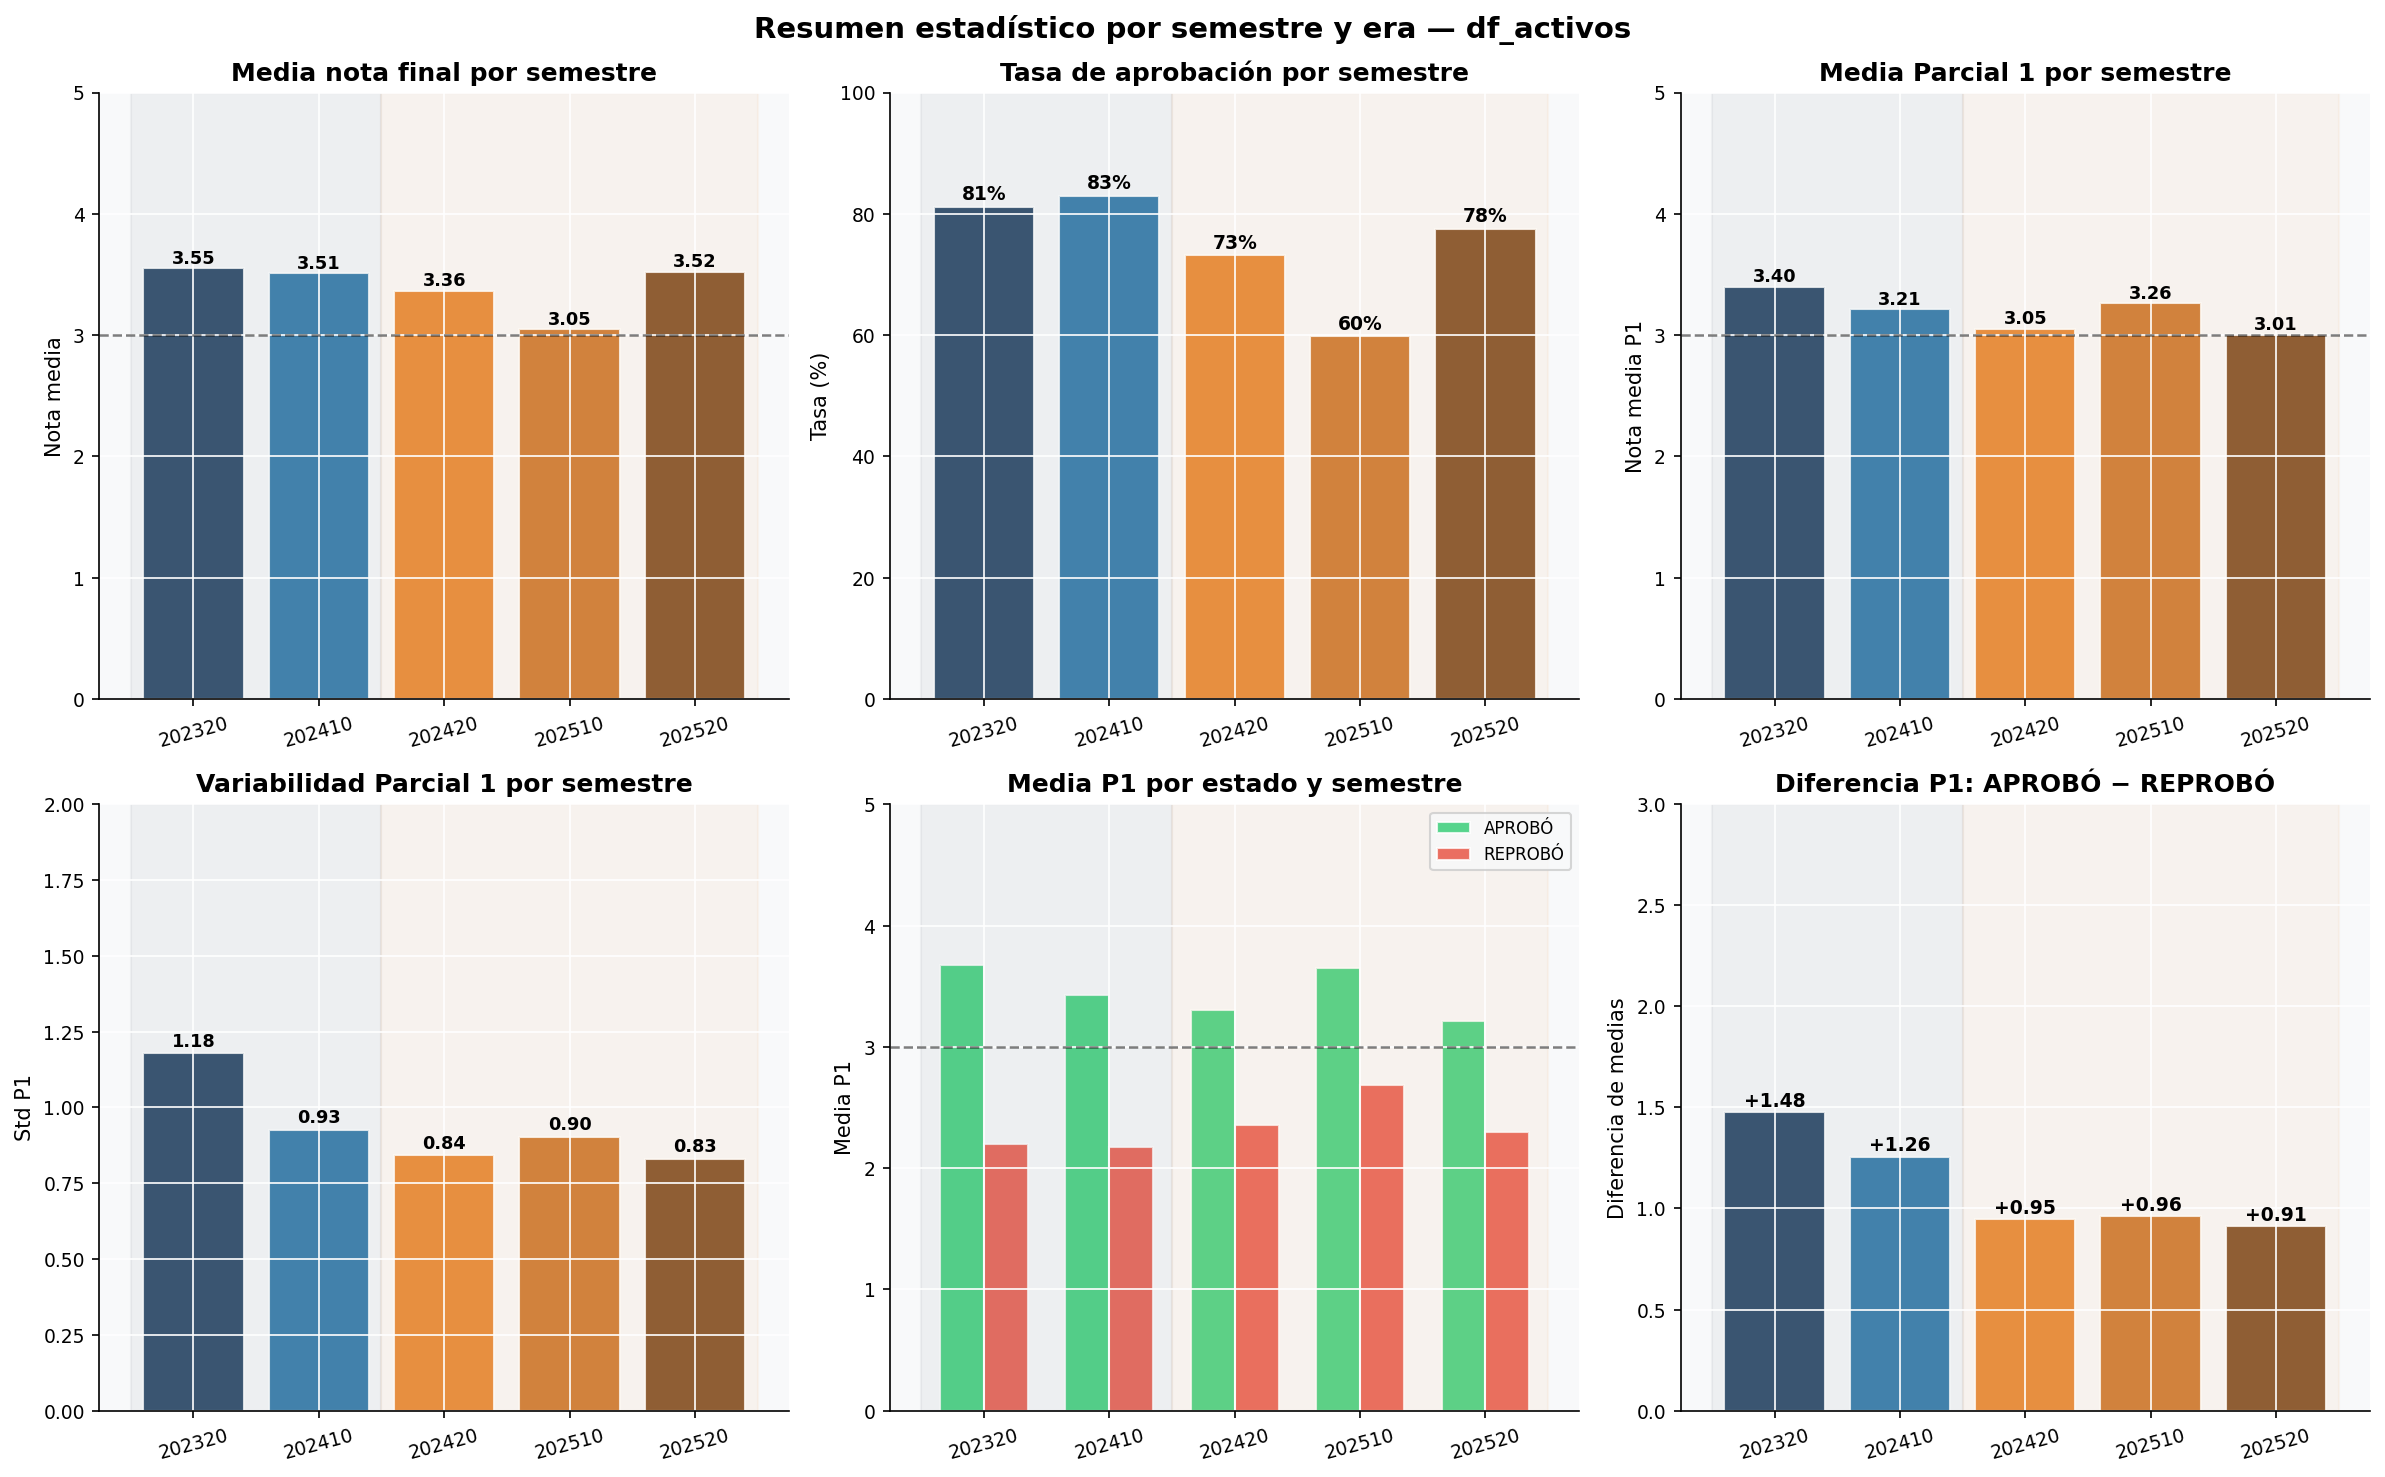

In [17]:
# ── Panel visual resumen 2×3 ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Resumen estadístico por semestre y era — df_activos',
             fontsize=14, fontweight='bold')

x       = np.arange(len(semestres))
colores = [PALETA_SEMESTRE[s] for s in semestres]

def barra_simple(ax, valores, ylabel, titulo, ylim=None, hline=None):
    bars = ax.bar(x, valores, color=colores, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([str(s) for s in semestres], rotation=15)
    ax.set_ylabel(ylabel); ax.set_title(titulo, fontweight='bold')
    if ylim: ax.set_ylim(*ylim)
    if hline: ax.axhline(hline, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
    ax.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

# 1. Nota media por semestre
barra_simple(axes[0,0],
    [df_activos[df_activos['semestre']==s]['nota_100'].mean() for s in semestres],
    'Nota media', 'Media nota final por semestre', (0, 5), 3.0)

# 2. Tasa de aprobación
tasas = [(df_activos[df_activos['semestre']==s]['estado']=='APROBÓ').mean()*100 for s in semestres]
bars2 = axes[0,1].bar(x, tasas, color=colores, alpha=0.85, edgecolor='white')
for bar, v in zip(bars2, tasas):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{v:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels([str(s) for s in semestres], rotation=15)
axes[0,1].set_ylabel('Tasa (%)'); axes[0,1].set_ylim(0, 100)
axes[0,1].set_title('Tasa de aprobación por semestre', fontweight='bold')
axes[0,1].axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
axes[0,1].axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

# 3. Media P1 por semestre
barra_simple(axes[0,2],
    [df_activos[df_activos['semestre']==s]['parcial_1'].mean() for s in semestres],
    'Nota media P1', 'Media Parcial 1 por semestre', (0, 5), 3.0)

# 4. Std P1 por semestre
barra_simple(axes[1,0],
    [df_activos[df_activos['semestre']==s]['parcial_1'].std() for s in semestres],
    'Std P1', 'Variabilidad Parcial 1 por semestre', (0, 2))

# 5. P1 media APROBÓ vs REPROBÓ agrupado
ax5 = axes[1,1]; w = 0.35
for j, (estado, color) in enumerate([('APROBÓ', PALETA_ESTADO['APROBÓ']),
                                       ('REPROBÓ', PALETA_ESTADO['REPROBÓ'])]):
    vals = [df_activos[(df_activos['semestre']==s) & (df_activos['estado']==estado)]['parcial_1'].mean()
            for s in semestres]
    ax5.bar(x + j*w - w/2, vals, width=w, color=color, alpha=0.8,
            label=estado, edgecolor='white')
ax5.set_xticks(x); ax5.set_xticklabels([str(s) for s in semestres], rotation=15)
ax5.set_ylabel('Media P1'); ax5.set_ylim(0, 5)
ax5.axhline(3.0, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax5.set_title('Media P1 por estado y semestre', fontweight='bold')
ax5.legend(fontsize=8)
ax5.axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
ax5.axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

# 6. Diferencia P1: APROBÓ - REPROBÓ
diffs = [
    df_activos[(df_activos['semestre']==s) & (df_activos['estado']=='APROBÓ')]['parcial_1'].mean() -
    df_activos[(df_activos['semestre']==s) & (df_activos['estado']=='REPROBÓ')]['parcial_1'].mean()
    for s in semestres
]
bars6 = axes[1,2].bar(x, diffs, color=colores, alpha=0.85, edgecolor='white')
for bar, v in zip(bars6, diffs):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'+{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels([str(s) for s in semestres], rotation=15)
axes[1,2].set_ylabel('Diferencia de medias'); axes[1,2].set_ylim(0, 3)
axes[1,2].set_title('Diferencia P1: APROBÓ − REPROBÓ', fontweight='bold')
axes[1,2].axvspan(-0.5, 1.5, alpha=0.05, color=PALETA_ERA['formato_antiguo'])
axes[1,2].axvspan(1.5, 4.5, alpha=0.05, color=PALETA_ERA['formato_nuevo'])

plt.tight_layout()
plt.savefig('../figures/02_resumen_estadisticos_semestre.png', bbox_inches='tight', dpi=150)
plt.show()